In [70]:
import pandas as pd
from pathlib import Path
import numpy as np
from scipy.stats import spearmanr, chi2_contingency, f_oneway
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Any, Tuple
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, MaxAbsScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support, accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve

from sklearn.feature_extraction.text import TfidfVectorizer 
 
import warnings
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from collections import Counter
 
import sklearn
from packaging import version     
 
from sklearn.linear_model import LogisticRegression  
from pandas.api.types import CategoricalDtype 
from imblearn.over_sampling import SMOTE
 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import lightgbm as lgb 

from sklearn.ensemble import IsolationForest
 
from scipy.sparse import hstack, csr_matrix  

from sklearn.metrics import classification_report

from sklearn.decomposition import PCA

In [8]:
# Load training dataset
DATA = Path.cwd() 
df = pd.read_csv("Bank_Transaction_Fraud_Detection.csv")

# EDA

In [3]:
df.head()

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com


In [4]:
# Check the number of rows and columns
print("Dataset Shape:")
print(df.shape)
print("\n" + "="*30 + "\n")

# Summary of the dataframe
print("Dataset Info:")
df.info()
print("\n" + "="*30 + "\n")

# Check for missing values in each column
print("Missing Values:")
print(df.isnull().sum())

Dataset Shape:
(200000, 24)


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Customer_ID              200000 non-null  object 
 1   Customer_Name            200000 non-null  object 
 2   Gender                   200000 non-null  object 
 3   Age                      200000 non-null  int64  
 4   State                    200000 non-null  object 
 5   City                     200000 non-null  object 
 6   Bank_Branch              200000 non-null  object 
 7   Account_Type             200000 non-null  object 
 8   Transaction_ID           200000 non-null  object 
 9   Transaction_Date         200000 non-null  object 
 10  Transaction_Time         200000 non-null  object 
 11  Transaction_Amount       200000 non-null  float64
 12  Merchant_ID              200000 non-null  object 
 13  Transaction_Typ

- 200,000 rows with 24 columns
- No missing values

- Features based on data type:
1. Numerical features: Age, Transaction_Amount, Account_Balance, Is_Fraud
2. Categorical: Gender, State, City, Bank_Branch, Account_Type, Merchant_ID, Transaction_Type, Merchant_Category, Transaction_Device, Transaction_Location, Device_Type, Transaction_Currency, Transaction_Description
3. Identifiers: Customer_ID, Customer_Name, Customer_Contact, Customer_Email, Transaction_ID
4. Datetime: Transaction_Date, Transaction_Time

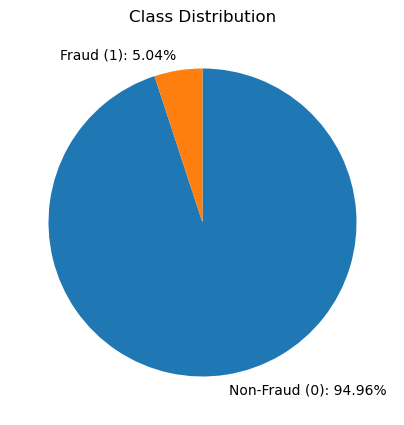

In [14]:
# counts & percents (keep 0=Non-Fraud, 1=Fraud order)
counts = df['Is_Fraud'].value_counts().reindex([0,1]).fillna(0).astype(int)
perc   = (counts / counts.sum() * 100)

labels = ['Non-Fraud (0)', 'Fraud (1)']

fig, ax = plt.subplots(figsize=(5,5))
ax.pie(perc.values, labels=[f'{lbl}: {p:.2f}%' for lbl,p in zip(labels, perc.values)],
       autopct=None, startangle=90, counterclock=False)
ax.set_title('Class Distribution')
plt.show()

- Fraud cases are much fewer than non-fraud
- Highly imbalanced dataset

In [14]:
# Summary statistics for numerical columns
print(df[['Transaction_Amount', 'Account_Balance', 'Age']].describe())

       Transaction_Amount  Account_Balance            Age
count       200000.000000    200000.000000  200000.000000
mean         49538.015554     52437.988784      44.015110
std          28551.874004     27399.507128      15.288774
min             10.290000      5000.820000      18.000000
25%          24851.345000     28742.395000      31.000000
50%          49502.440000     52372.555000      44.000000
75%          74314.625000     76147.670000      57.000000
max          98999.980000     99999.950000      70.000000


- No negative values
- No missing values for numerical features
- Distribution of values look normal

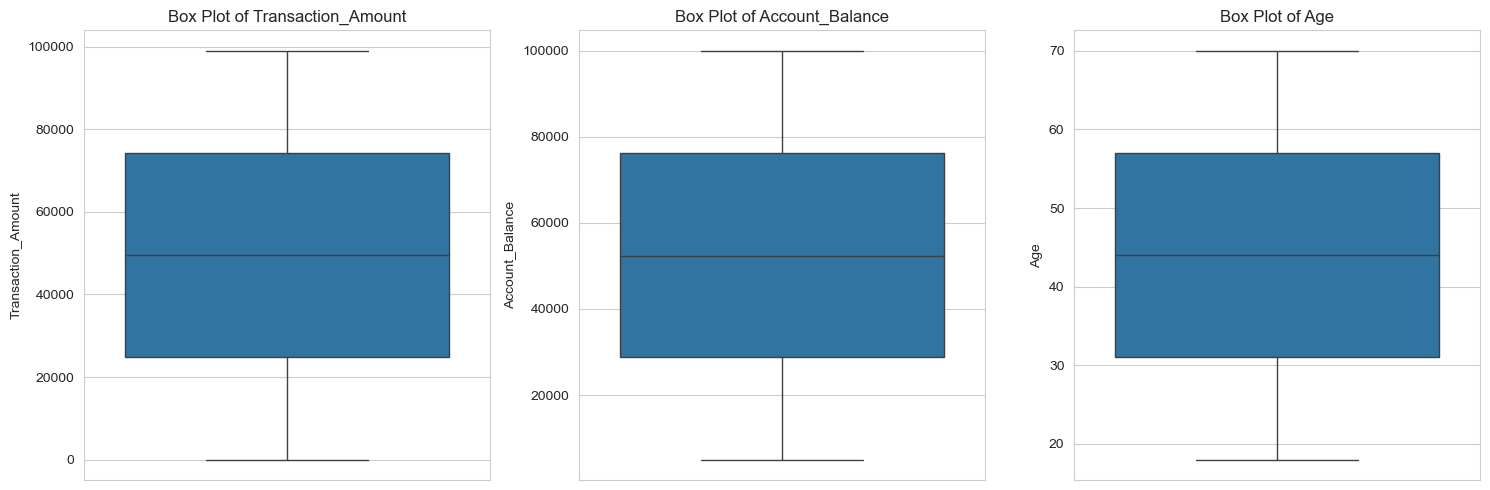

In [37]:
# List of numerical features
numerical_features = ['Transaction_Amount', 'Account_Balance', 'Age']

plt.figure(figsize=(15, 5))

# Loop through the numerical features and create a box plot for each
for i, column in enumerate(numerical_features):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)

plt.tight_layout()
plt.show()

- No extreme outliers

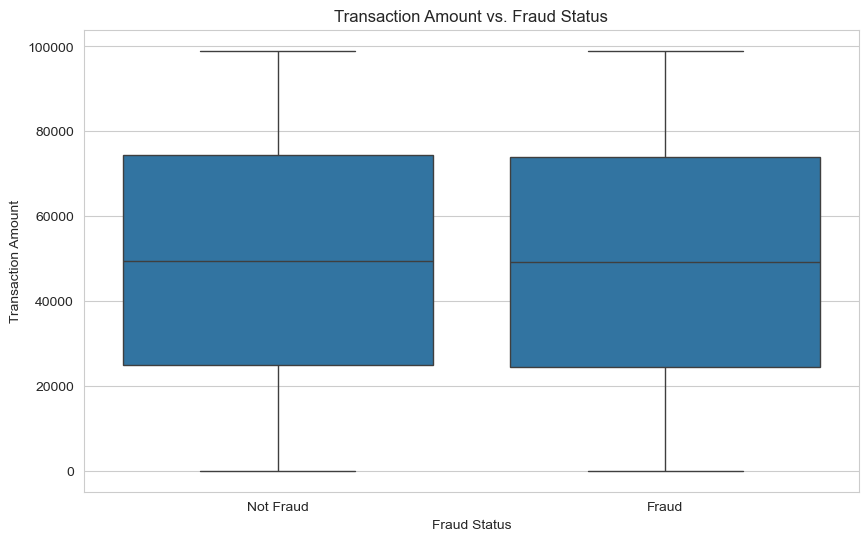

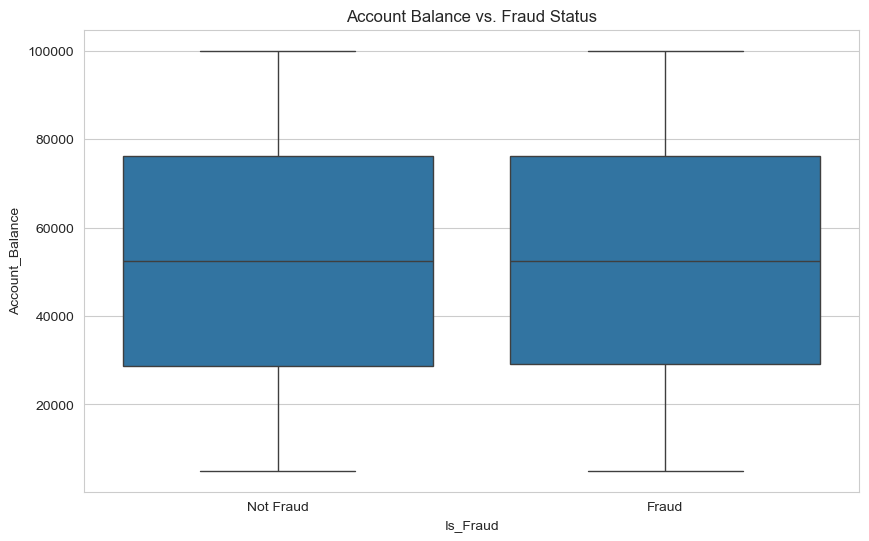

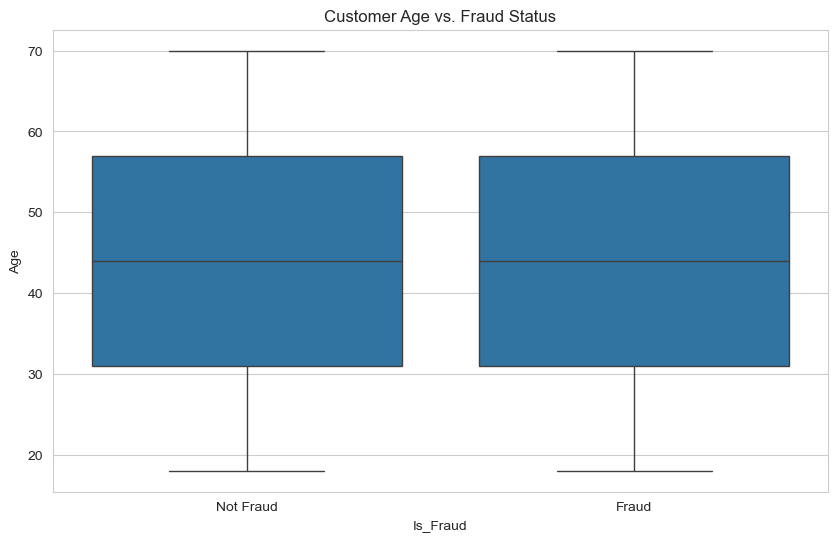

In [32]:
# Box plot for Transaction Amount
plt.figure(figsize=(10, 6))
sns.boxplot(x='Is_Fraud', y='Transaction_Amount', data=df)
plt.title('Transaction Amount vs. Fraud Status')
plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
plt.xlabel('Fraud Status')
plt.ylabel('Transaction Amount')
plt.show()

# Box plot for Account Balance
plt.figure(figsize=(10, 6))
sns.boxplot(x='Is_Fraud', y='Account_Balance', data=df)
plt.title('Account Balance vs. Fraud Status')
plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
plt.show()

# Box plot for Age
plt.figure(figsize=(10, 6))
sns.boxplot(x='Is_Fraud', y='Age', data=df)
plt.title('Customer Age vs. Fraud Status')
plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
plt.show()

- The distribution for Transaction Amount seems to be similar for both fraudulent and non-fraudulent cases
- The two distributions (Fraud vs Not Fraud) look almost identical — median, spread, and range are overlapping. This means transaction amount alone is not a strong fraud indicator. Fraudsters don’t necessarily make only large transactions.

- The distribution for Account Balance seems to be similar for both fraudulent and non-fraudulent cases
- There’s no obvious difference in account balance between fraud and non-fraud users.


- The distribution for Customer Age seems to be similar for both fraudulent and non-fraudulent cases
- Age doesn’t appear to have a strong influence on fraud probability.

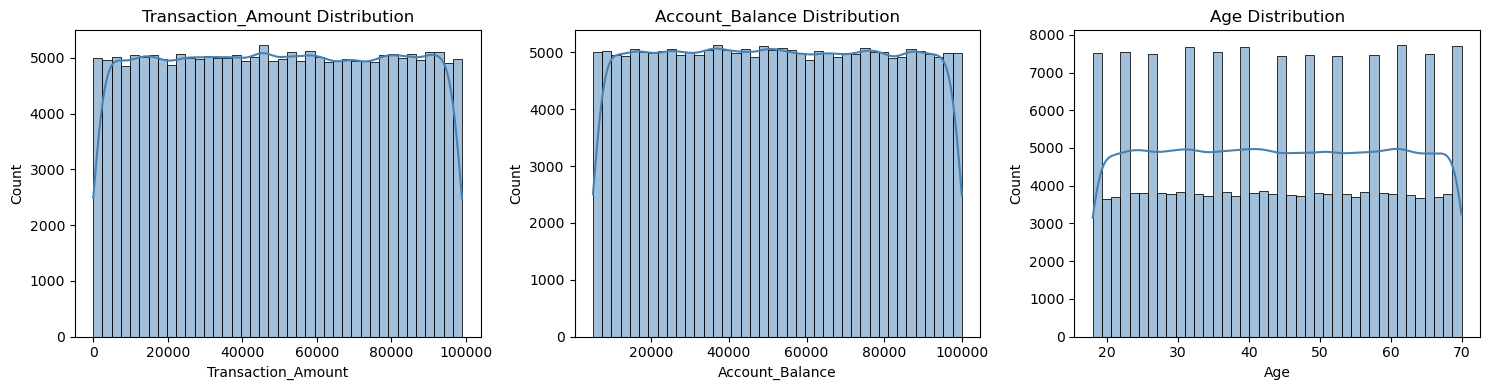

In [38]:
# Check distribution of numerical features
num_cols = ['Transaction_Amount', 'Account_Balance', 'Age']

plt.figure(figsize=(15, 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True, color='steelblue', bins=40)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
plt.tight_layout()
plt.show()


- Numerical features are balanced in value ranges and doesn’t have heavy-tail distributions

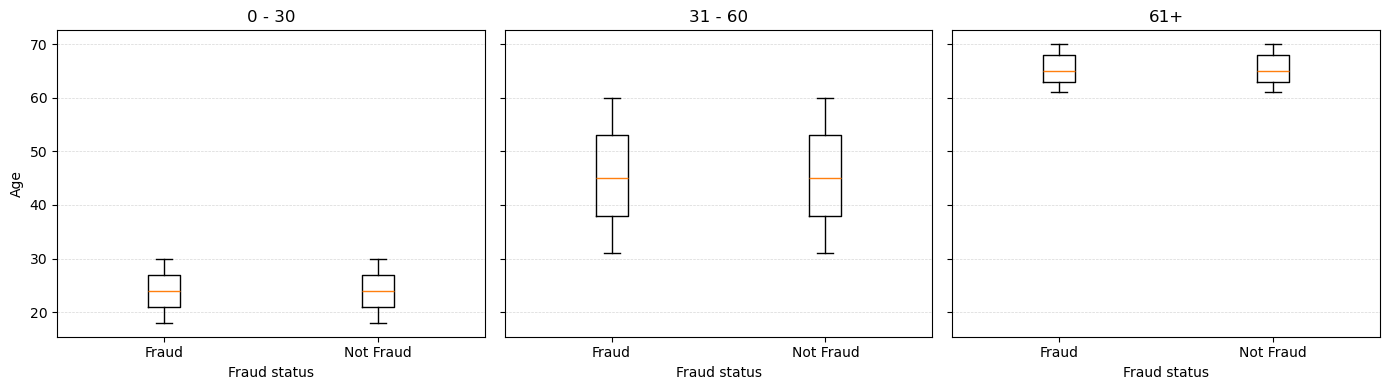

In [14]:
# Distribution of age group and fraud status

bins   = [0, 30, 60, np.inf]
labels = ["0 - 30", "31 - 60", "61+"]
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True, include_lowest=True)
 
df["Fraud_Status"] = np.where(df["Is_Fraud"].astype(int) == 1, "Fraud", "Not Fraud")

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, grp in zip(axes, labels):
    sub = df[df["Age_Group"] == grp] 
    data = [
        sub.loc[sub["Fraud_Status"] == "Fraud", "Age"].dropna().values,
        sub.loc[sub["Fraud_Status"] == "Not Fraud", "Age"].dropna().values
    ]
    ax.boxplot(data, tick_labels=["Fraud", "Not Fraud"], showfliers=False)
    ax.set_title(grp)
    ax.set_xlabel("Fraud status")
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

axes[0].set_ylabel("Age")
plt.tight_layout()
plt.show()

- By plotting the fraud status by age group, we can see that fraudulent and legitimate transactions occur evenly across all age groups

Fraud Rate by Merchant Category (%):
Merchant_Category
Clothing         5.200960
Groceries        5.188779
Restaurant       5.035048
Electronics      5.031578
Health           4.985204
Entertainment    4.823315
Name: Is_Fraud, dtype: float64


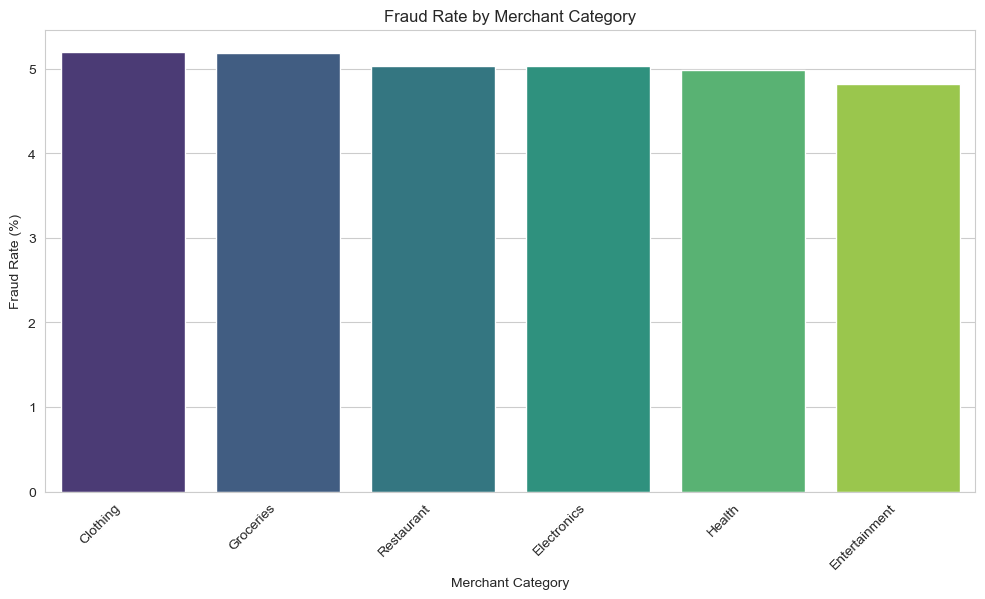

In [22]:
# Calculate the fraud rate for each merchant category
fraud_rate_merchant = df.groupby('Merchant_Category')['Is_Fraud'].mean().sort_values(ascending=False) * 100

print("Fraud Rate by Merchant Category (%):")
print(fraud_rate_merchant)

plt.figure(figsize=(12, 6))
sns.barplot(x=fraud_rate_merchant.index, y=fraud_rate_merchant.values, hue=fraud_rate_merchant.index, palette='viridis', legend=False)
plt.title('Fraud Rate by Merchant Category')
plt.xlabel('Merchant Category')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45, ha='right') 
plt.show()

- The fraud rate per category show very similar percentages across all merchant categories. There’s no single merchant category that stands out as riskier or more targeted by fraudsters.
- Fraudulent activity is evenly distributed across transaction types — possibly suggesting fraud patterns are driven more by behavioral or temporal factors rather than the type of merchant itself.

Fraud Rate by Transaction Type (%):
Transaction_Type
Transfer        5.188597
Credit          5.097063
Debit           5.076155
Withdrawal      4.929985
Bill Payment    4.927572
Name: Is_Fraud, dtype: float64


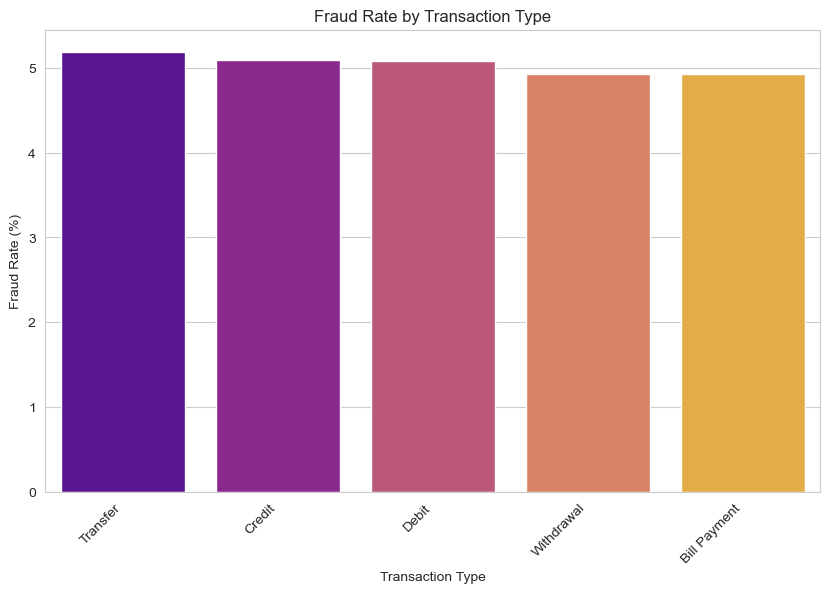

In [23]:
# Calculate the fraud rate for each transaction type
fraud_rate_type = df.groupby('Transaction_Type')['Is_Fraud'].mean().sort_values(ascending=False) * 100

print("Fraud Rate by Transaction Type (%):")
print(fraud_rate_type)

plt.figure(figsize=(10, 6))
sns.barplot(x=fraud_rate_type.index, y=fraud_rate_type.values, hue=fraud_rate_type.index, palette='plasma', legend=False)
plt.title('Fraud Rate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.show()

- All transaction types have similar fraud likelihoods, with Transfer transactions showing a marginally higher rate. However, the overall pattern indicates that transaction type alone is not a strong indicator for fraud.

Fraud Rate by Account Type (%):
Account_Type
Business    5.168238
Savings     5.029057
Checking    4.935449
Name: Is_Fraud, dtype: float64


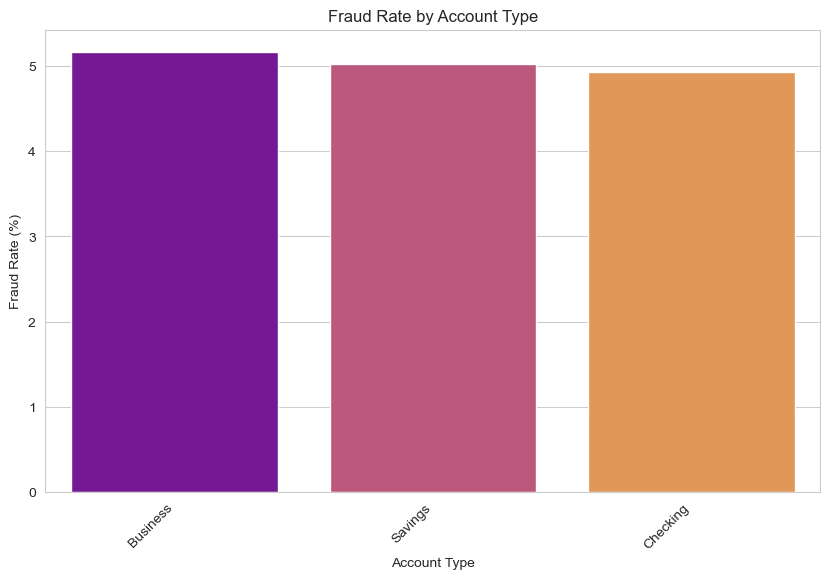

In [26]:
# Calculate the fraud rate for each account type
fraud_rate_type = df.groupby('Account_Type')['Is_Fraud'].mean().sort_values(ascending=False) * 100

print("Fraud Rate by Account Type (%):")
print(fraud_rate_type)

plt.figure(figsize=(10, 6))
sns.barplot(x=fraud_rate_type.index, y=fraud_rate_type.values, hue=fraud_rate_type.index, palette='plasma', legend=False)
plt.title('Fraud Rate by Account Type')
plt.xlabel('Account Type')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.show()

- Fraud rates across Business, Savings, and Checking accounts are nearly identical.
- Account type alone does not meaningfully predict fraud

Fraud Rate by Device Type (%):
Device_Type
Desktop    5.101059
POS        5.054778
ATM        5.030466
Mobile     4.989792
Name: Is_Fraud, dtype: float64


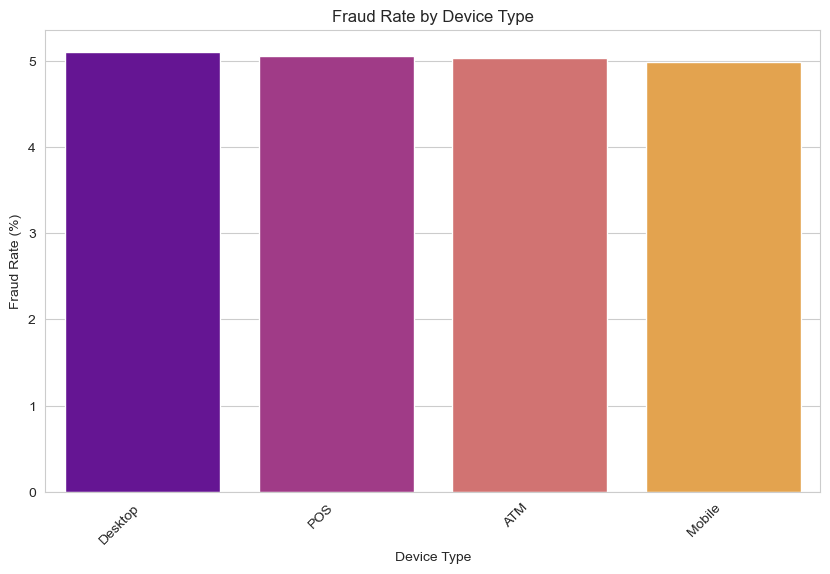

In [29]:
# Calculate the fraud rate for each device type
fraud_rate_type = df.groupby('Device_Type')['Is_Fraud'].mean().sort_values(ascending=False) * 100

print("Fraud Rate by Device Type (%):")
print(fraud_rate_type)

plt.figure(figsize=(10, 6))
sns.barplot(x=fraud_rate_type.index, y=fraud_rate_type.values, hue=fraud_rate_type.index, palette='plasma', legend=False)
plt.title('Fraud Rate by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.show()

- Fraud rate across device types seems to be quite uniform (~5%)

Fraud Rate by Transaction Device (%):
Transaction_Device
Debit/Credit Card               5.499819
Virtual Card                    5.447326
Biometric Scanner               5.394869
Payment Gateway Device          5.359411
QR Code Scanner                 5.177627
Voice Assistant                 5.125016
ATM Booth Kiosk                 5.116081
Web Browser                     5.112141
Desktop/Laptop                  5.101154
POS Mobile Device               5.071197
Smart Card                      5.053486
Tablet                          5.050254
Mobile Device                   5.038710
POS Mobile App                  4.969497
Wearable Device                 4.908957
ATM                             4.872642
Self-service Banking Machine    4.869397
Bank Branch                     4.774029
Banking Chatbot                 4.727955
POS Terminal                    4.650866
Name: Is_Fraud, dtype: float64


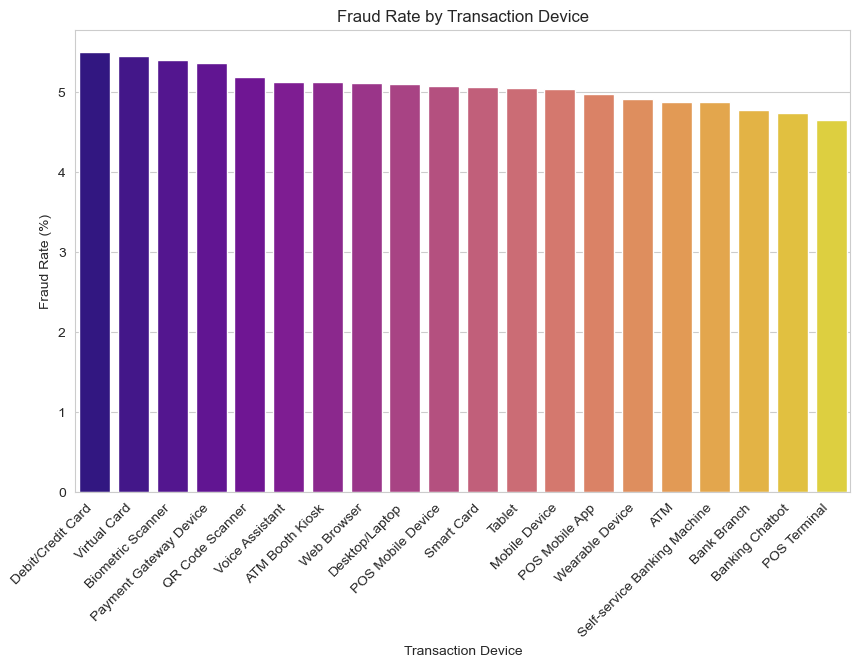

In [30]:
# Calculate the fraud rate for each transaction device 
fraud_rate_type = df.groupby('Transaction_Device')['Is_Fraud'].mean().sort_values(ascending=False) * 100

print("Fraud Rate by Transaction Device (%):")
print(fraud_rate_type)

plt.figure(figsize=(10, 6))
sns.barplot(x=fraud_rate_type.index, y=fraud_rate_type.values, hue=fraud_rate_type.index, palette='plasma', legend=False)
plt.title('Fraud Rate by Transaction Device')
plt.xlabel('Transaction Device')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.show()

- Fraud is slightly more common in card-based and online payment devices, while in-person or authenticated devices like POS terminals and ATMs show marginally lower risk. 
- Nonetheless, the overall difference is under 1%, suggesting that transaction device alone is not a major distinguishing factor.”

In [26]:
# Combine date and time into a single column and convert to datetime objects
fmt = "%d-%m-%Y %H:%M:%S"

dt_str = (df["Transaction_Date"].astype(str).str.strip()
          + " " +
          df["Transaction_Time"].astype(str).str.strip())

df["Transaction_DateTime"] = pd.to_datetime(dt_str, format=fmt, errors="coerce")

# Extract the hour of the day
df['Transaction_Hour'] = df['Transaction_DateTime'].dt.hour

# Extract the day of the week (Monday=0, Sunday=6)
df['Day_Of_Week'] = df['Transaction_DateTime'].dt.dayofweek

print("New time-based features created:")
print(df[['Transaction_DateTime', 'Transaction_Hour', 'Day_Of_Week']].head())

New time-based features created:
  Transaction_DateTime  Transaction_Hour  Day_Of_Week
0  2025-01-23 16:04:07                16            3
1  2025-01-11 17:14:53                17            5
2  2025-01-25 03:09:52                 3            5
3  2025-01-19 12:27:02                12            6
4  2025-01-30 18:30:46                18            3


Fraud Rate by Transaction Hour (%):
Transaction_Hour
0     5.322062
1     5.068957
2     5.113090
3     5.234722
4     5.265056
5     4.752806
6     5.179666
7     4.679600
8     5.144156
9     5.284453
10    5.023810
11    5.146883
12    4.675514
13    5.135555
14    4.779934
15    5.163818
16    4.872805
17    5.095158
18    5.207957
19    4.669261
20    5.031978
21    4.992162
22    5.075054
23    5.147771
Name: Is_Fraud, dtype: float64


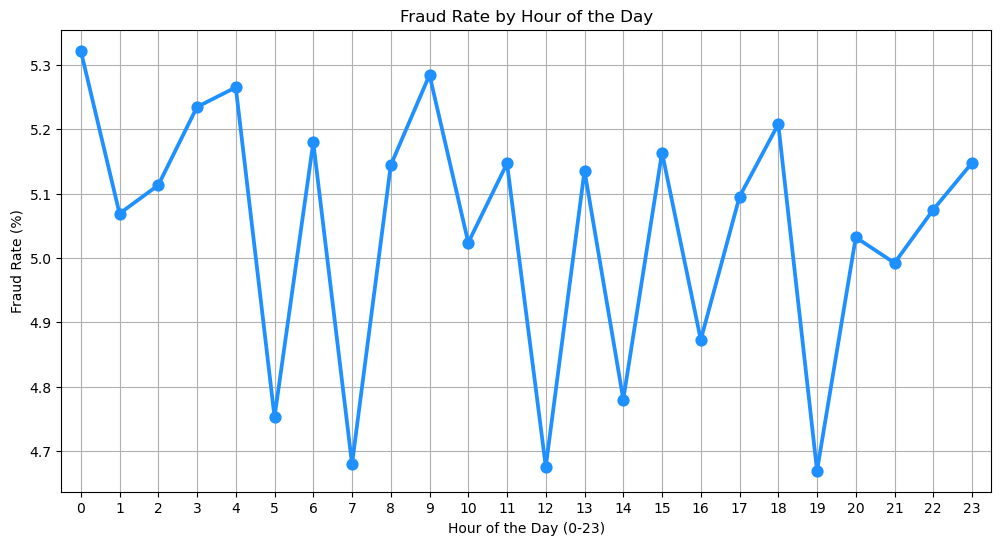

In [27]:
# Calculate the fraud rate for each hour
fraud_rate_hour = df.groupby('Transaction_Hour')['Is_Fraud'].mean().sort_index() * 100

print("Fraud Rate by Transaction Hour (%):")
print(fraud_rate_hour)

plt.figure(figsize=(12, 6))
sns.pointplot(x=fraud_rate_hour.index, y=fraud_rate_hour.values, color='dodgerblue')
plt.title('Fraud Rate by Hour of the Day')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Fraud Rate (%)')
plt.grid(True)
plt.show()

- Fraudulent transactions spiked at 12am, 4am, 6am, 8-9am, 1pm, 3pm, 5pm, 7pm, 11pm
- Fraudulent transactions show a mild tendency to occur more frequently during late-night hours (12AM to 4AM) and late evenings (around 10PM to 11PM). This could reflect opportunistic activity when users and monitoring systems are less active, though the overall variation remains small

Fraud rate by time bucket (%):
         Time_Bucket  FraudRate
0     Midnight (0–5)      5.126
1     Morning (6–11)      5.074
2  Afternoon (12–17)      4.954
3    Evening (18–23)      5.021


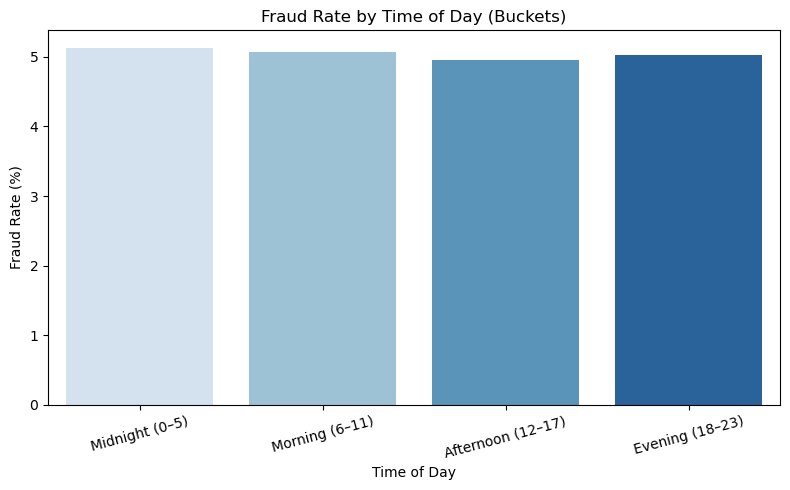


Fraud rate by day of week (%):
DayName
Mon    5.174
Tue    4.948
Wed    5.168
Thu    5.080
Fri    5.085
Sat    4.731
Sun    5.084
Name: Is_Fraud, dtype: float64


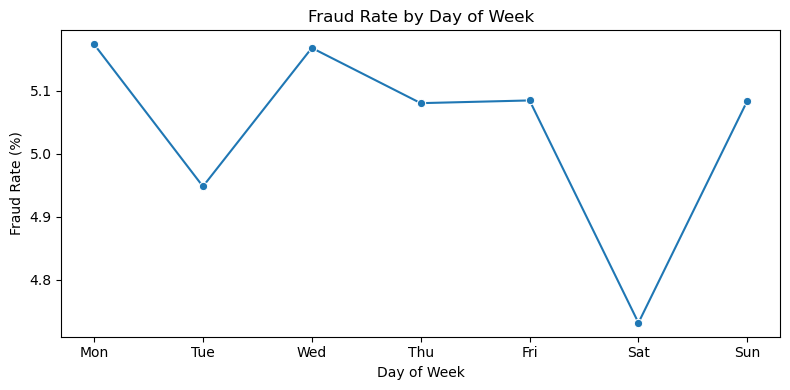

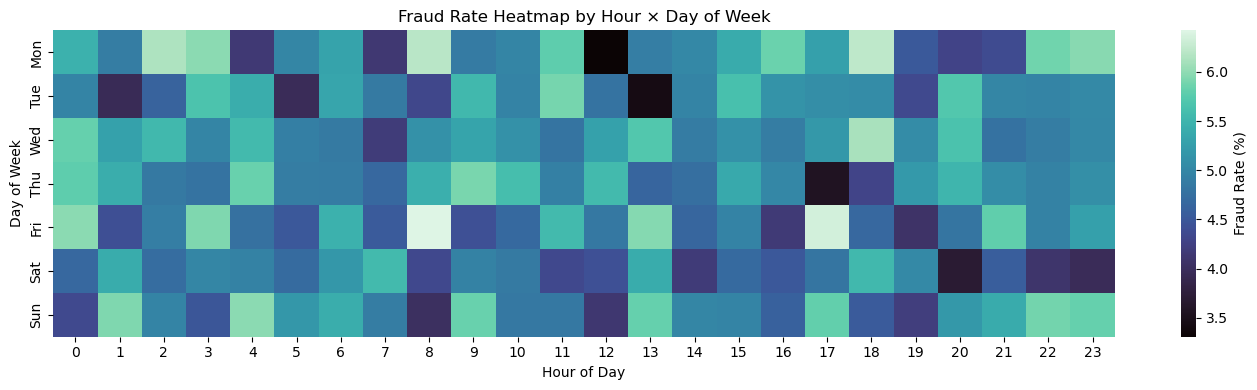

In [31]:
bins   = [0, 6, 12, 18, 24]
labels = ["Midnight (0–5)", "Morning (6–11)", "Afternoon (12–17)", "Evening (18–23)"]

df["Time_Bucket"] = pd.cut(df["Transaction_Hour"], bins=bins, right=False, labels=labels)
 

cat = CategoricalDtype(categories=labels, ordered=True)
df["Time_Bucket"] = df["Time_Bucket"].astype(cat)

# Compute fraud rate per bucket (in %)
fraud_rate_bucket = (
    df.groupby("Time_Bucket", observed=True)["Is_Fraud"]
      .mean()
      .mul(100)
      .reset_index(name="FraudRate")
)

print("Fraud rate by time bucket (%):")
print(fraud_rate_bucket.round(3))

plt.figure(figsize=(8,5))
sns.barplot(
    data=fraud_rate_bucket,
    x="Time_Bucket", y="FraudRate",
    hue="Time_Bucket", palette="Blues", dodge=False, legend=False
)
plt.ylabel("Fraud Rate (%)")
plt.xlabel("Time of Day")
plt.title("Fraud Rate by Time of Day (Buckets)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
 
# Fraud rate by day of week
dow_map = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
fraud_rate_dow = (
    df.assign(DayName=df["Day_Of_Week"].map(dow_map))
      .groupby("DayName")["Is_Fraud"].mean().mul(100)
      .reindex(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
)

print("\nFraud rate by day of week (%):")
print(fraud_rate_dow.round(3))

plt.figure(figsize=(8,4))
sns.lineplot(x=fraud_rate_dow.index, y=fraud_rate_dow.values, marker="o")
plt.ylabel("Fraud Rate (%)"); plt.xlabel("Day of Week")
plt.title("Fraud Rate by Day of Week")
plt.tight_layout(); plt.show()

# Heatmap: hr x day of week
pivot = (
    df.assign(DayName=df["Day_Of_Week"].map(dow_map))
      .pivot_table(index="DayName", columns="Transaction_Hour",
                   values="Is_Fraud", aggfunc="mean")
      .reindex(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
      .mul(100)
)

plt.figure(figsize=(14,4))
sns.heatmap(pivot, annot=False, cmap="mako", cbar_kws={"label":"Fraud Rate (%)"})
plt.title("Fraud Rate Heatmap by Hour × Day of Week")
plt.xlabel("Hour of Day"); plt.ylabel("Day of Week")
plt.tight_layout(); plt.show()

- Fraudulent activity happens throughout the day and week, without extreme concentration.
- There’s a slight increase during midnight hours and weekdays, possibly linked to automated or low-visibility transactions.

In [27]:
# Check the unique transaction descriptions and their frequencies
description_counts = df['Transaction_Description'].value_counts()

print("Transaction Description Counts:")
print(description_counts)

Transaction Description Counts:
Transaction_Description
Sports ticket                1268
Home appliance repair        1257
Taxi fare                    1248
Seminar registration         1246
Taxi booking                 1240
                             ... 
Food subscription            1098
Loyalty points redemption    1093
Penalty fee                  1092
Online subscription          1080
Medical treatment payment    1071
Name: count, Length: 172, dtype: int64


In [18]:
# Calculate the fraud rate for each description
fraud_rate_desc = df.groupby('Transaction_Description')['Is_Fraud'].mean() * 100

riskiest_descriptions = fraud_rate_desc.sort_values(ascending=False)
safest_descriptions = fraud_rate_desc.sort_values(ascending=True)

BOLD = "\033[1m"
RESET = "\033[0m"

print(f"{BOLD}Top 5 Riskiest Transaction Descriptions{RESET}")
print(riskiest_descriptions.head(5))
print("\n" + "="*45 + "\n")

print(f"{BOLD}Top 5 Safest Transaction Descriptions{RESET}")
print(safest_descriptions.head(5))

Top 5 Riskiest Transaction Descriptions
Transaction_Description
Travel agency payment        6.423611
Taxi fare                    6.410256
Crowdfunding contribution    6.333333
Streaming subscription       6.309421
Pet care                     6.283662
Name: Is_Fraud, dtype: float64


Top 5 Safest Transaction Descriptions
Transaction_Description
Camping gear purchase    3.664921
Lunch payment            3.771930
School fee payment       3.836530
Online fitness class     3.862661
Online subscription      3.888889
Name: Is_Fraud, dtype: float64


- Fraud rates are highest for transactions that are either low in amount (like taxi fares) or involve external entities (travel, crowdfunding).
- Safer transactions are tied to routine or verifiable activities, showing that normal personal spending (food, education, recurring payments) tends to have much lower fraud rates.

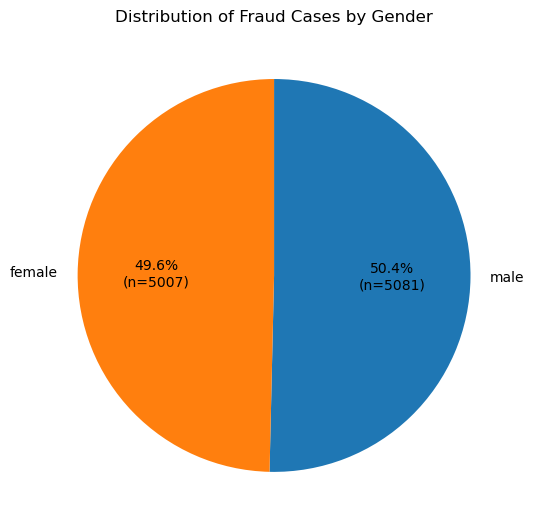

In [13]:
# Fraud rate by gender 
fraud_df = df[df["Is_Fraud"].astype(int) == 1]
counts = fraud_df["Gender"].value_counts(dropna=False)
labels = counts.index.astype(str)
sizes  = counts.values

# helper to show both % and count
def autopct_fmt(vals):
    def _fmt(pct):
        total = vals.sum()
        cnt = int(round(pct*total/100.0))
        return f"{pct:.1f}%\n(n={cnt})"
    return _fmt
 
plt.figure(figsize=(5.5,5.5))
plt.pie(
    sizes, labels=labels, autopct=autopct_fmt(counts),
    startangle=90, counterclock=False
)
plt.title("Distribution of Fraud Cases by Gender")
plt.tight_layout()
plt.show()

- Fraud appears to occur almost equally across genders, suggesting that gender alone does not influence the likelihood of fraudulent behavior.

# Correlation Analysis

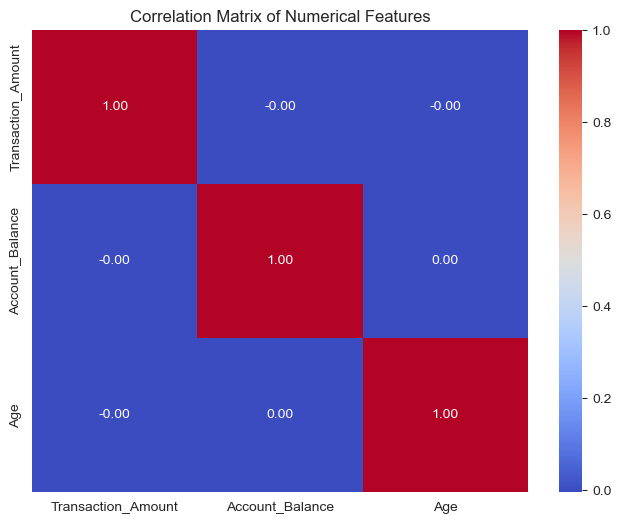

                    Transaction_Amount  Account_Balance       Age
Transaction_Amount            1.000000        -0.001735 -0.003087
Account_Balance              -0.001735         1.000000  0.000269
Age                          -0.003087         0.000269  1.000000


In [34]:
# List of numerical columns
numerical_features = df[['Transaction_Amount', 'Account_Balance', 'Age']]

# Calculate the correlation matrix
correlation_matrix = numerical_features.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print(correlation_matrix)

- From the correlation matrix, we can see that numeric variables (Transaction_Amount, Account_Balance, and Age) are largely independent, with negligible pairwise relationships. This suggests that fraud patterns are not explained by simple linear relationships among numeric variables but may instead arise from categorical or interaction terms.

In [35]:
contingency_table = pd.crosstab(df['Merchant_Category'], df['Transaction_Type'])

# Perform Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Test Results for Merchant_Category vs. Transaction_Type")
print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Result: There is a statistically significant association between the features.")
else:
    print("Result: There is no statistically significant association between the features.")

Chi-Square Test Results for Merchant_Category vs. Transaction_Type
Chi-Square Statistic: 21.61
P-value: 0.36206089588246626
Result: There is no statistically significant association between the features.


In [35]:
cat_features = [
    "Gender", "State", "City", "Bank_Branch", "Account_Type",
    "Transaction_Type", "Merchant_Category", "Transaction_Device",
    "Device_Type", "Transaction_Currency"
]

# Run Chi-Square Test for each feature vs Is_Fraud
for col in cat_features:
    contingency_table = pd.crosstab(df[col], df["Is_Fraud"])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"{col:25s} | χ² = {chi2:.2f} | p = {p:.5f} | df = {dof} | Significant? {'✅ Yes' if p < 0.05 else '❌ No'}")

Gender                    | χ² = 0.08 | p = 0.77949 | df = 1 | Significant? ❌ No
State                     | χ² = 30.45 | p = 0.59471 | df = 33 | Significant? ❌ No
City                      | χ² = 153.72 | p = 0.27448 | df = 144 | Significant? ❌ No
Bank_Branch               | χ² = 153.72 | p = 0.27448 | df = 144 | Significant? ❌ No
Account_Type              | χ² = 3.82 | p = 0.14808 | df = 2 | Significant? ❌ No
Transaction_Type          | χ² = 4.28 | p = 0.36949 | df = 4 | Significant? ❌ No
Merchant_Category         | χ² = 6.82 | p = 0.23429 | df = 5 | Significant? ❌ No
Transaction_Device        | χ² = 19.27 | p = 0.43993 | df = 19 | Significant? ❌ No
Device_Type               | χ² = 0.68 | p = 0.87864 | df = 3 | Significant? ❌ No
Transaction_Currency      | χ² = 0.00 | p = 1.00000 | df = 0 | Significant? ❌ No


- A Chi-Square test of independence was conducted to assess the relationship between categorical features and the target variable (Is_Fraud).
- Across all categorical features, no statistically significant associations were found (all p-values > 0.05).
- This indicates that fraud occurrences are uniformly distributed across demographic, transactional, and device-related categories, suggesting that categorical variables alone do not strongly distinguish fraudulent transactions. 

# Unigram-bigram analysis on transaction description

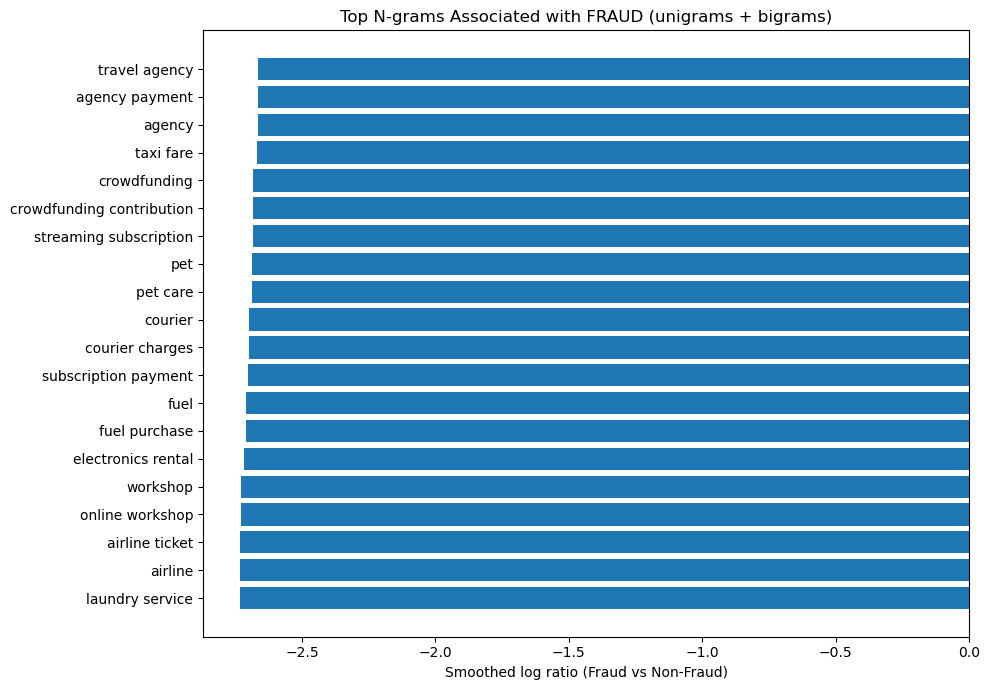

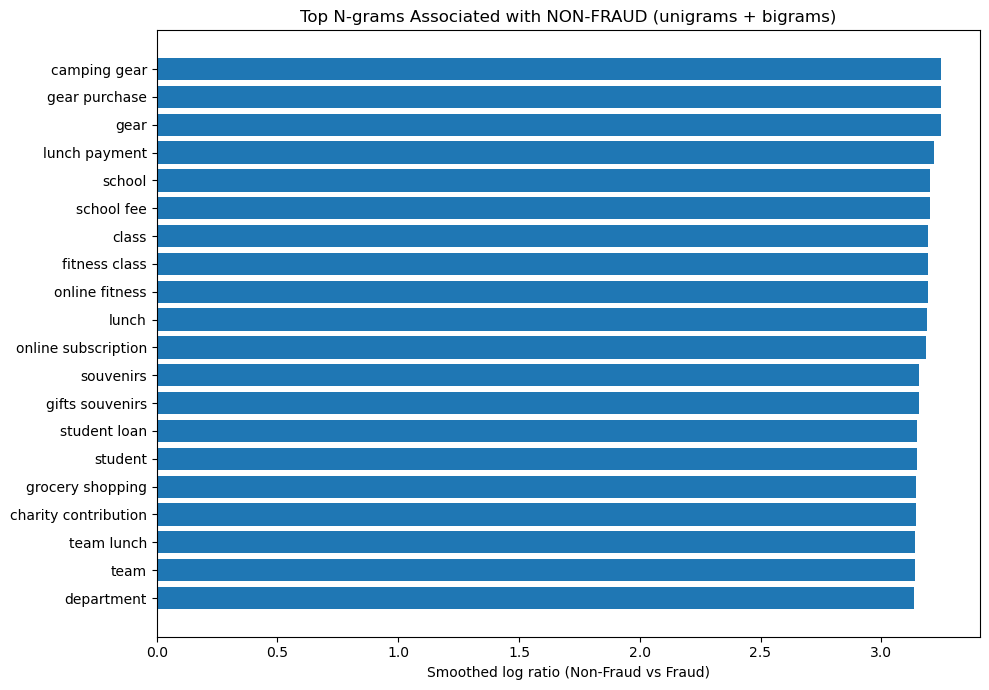

In [36]:
MIN_DF   = 20     
TOP_K    = 20     

texts = (
    df["Transaction_Description"]
      .fillna("")
      .astype(str)
      .str.lower()
      .str.replace(r"[^a-z\s]", " ", regex=True)
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
)
y = df["Is_Fraud"].astype(int).to_numpy()
fraud_mask = (y == 1)
non_mask   = ~fraud_mask

# vectorize (unigram + bigram) 
vec = CountVectorizer(ngram_range=(1, 2), min_df=MIN_DF, stop_words="english")
X_text = vec.fit_transform(texts)
vocab  = np.array(vec.get_feature_names_out())

# counts by class 
fraud_counts = np.asarray(X_text[fraud_mask, :].sum(axis=0)).ravel()
non_counts   = np.asarray(X_text[non_mask,  :].sum(axis=0)).ravel()

# smoothed log ratio score (Fraud vs Non-Fraud)
fraud_s = fraud_counts + 1
non_s   = non_counts + 1
log_ratio = np.log(fraud_s / non_s)

terms_df = pd.DataFrame({
    "term": vocab,
    "fraud_count": fraud_counts,
    "non_count": non_counts,
    "log_ratio": log_ratio
})

# top K skewed to Fraud (largest positive log_ratio) 
top_fraud = (terms_df.sort_values("log_ratio", ascending=False)
                       .head(TOP_K)
                       .reset_index(drop=True))

plt.figure(figsize=(10, 7))
ypos = np.arange(len(top_fraud))
plt.barh(ypos, top_fraud["log_ratio"])
plt.yticks(ypos, top_fraud["term"])
plt.xlabel("Smoothed log ratio (Fraud vs Non-Fraud)")
plt.title("Top N-grams Associated with FRAUD (unigrams + bigrams)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# top K skewed to Non-Fraud (most negative log_ratio)
top_non = (terms_df.sort_values("log_ratio", ascending=True)
                     .head(TOP_K)
                     .reset_index(drop=True))

plt.figure(figsize=(10, 7))
ypos = np.arange(len(top_non))
plt.barh(ypos, -top_non["log_ratio"])
plt.yticks(ypos, top_non["term"])
plt.xlabel("Smoothed log ratio (Non-Fraud vs Fraud)")
plt.title("Top N-grams Associated with NON-FRAUD (unigrams + bigrams)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

- Fraudulent transactions are more of “travel agency,” “agency payment,” “crowdfunding contribution,” “streaming subscription,” and “airline ticket.” These descriptions typically relate to online or remote transactions, which are more susceptible to unauthorized use and card-not-present fraud.
- Non-fraudulent transactions commonly included terms like “school fee,” “lunch payment,” “fitness class,” “charity contribution,” and “grocery shopping,” reflecting routine, low-risk consumer spending.

# Data Preprocessing

In [3]:
def _safe_div(num, den):
    den = den.replace(0, np.nan)
    out = num / den
    return out.replace([np.inf, -np.inf], np.nan).fillna(0.0)

def _freq_encode(series: pd.Series) -> pd.Series:
    freq = series.value_counts(normalize=True)
    return series.map(freq).astype(float).fillna(0.0)

def build_clean_inputs(
    df: pd.DataFrame,
    target_col: str = "Is_Fraud",
    write_path: str = "cleandata.csv",
    keep_raw_cats: list | None = None,
):
    """
      - parse datetime -> hour/day of week/weekend/night
      - numeric transforms (ratio, log, high-value flag)
      - one-hot low-card categoricals
      - freq-encode high-card categoricals
      - keep selected raw high-card categoricals (for later target encodings)
      - drop IDs/text/raw dates
    """
    df = df.copy()
    keep_raw_cats = keep_raw_cats or [
        "Merchant_Category", "Transaction_Device", "City", "State", "Transaction_Type", "Transaction_Location", "Transaction_Description"
    ]

    for c in ["Age", "Transaction_Amount", "Account_Balance"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # datetime to features 
    if "Transaction_DateTime" in df.columns:
        df["Transaction_DateTime"] = pd.to_datetime(df["Transaction_DateTime"], errors="coerce")
    elif {"Transaction_Date", "Transaction_Time"}.issubset(df.columns):
        df["Transaction_DateTime"] = pd.to_datetime(
            df["Transaction_Date"].astype(str) + " " + df["Transaction_Time"].astype(str),
            errors="coerce"
        )
    else:
        df["Transaction_DateTime"] = pd.NaT

    df["Transaction_Hour"] = df["Transaction_DateTime"].dt.hour
    df["Day_Of_Week"] = df["Transaction_DateTime"].dt.dayofweek
    df["Is_Weekend"] = df["Day_Of_Week"].isin([5, 6]).astype(int)
    df["Is_Night_Transaction"] = df["Transaction_Hour"].between(0, 5).astype(int)

    for c in ["Transaction_Hour", "Day_Of_Week"]:
        df[c] = df[c].fillna(-1).astype(int)

    # numeric features
    if {"Transaction_Amount", "Account_Balance"}.issubset(df.columns):
        df["Amount_to_Balance_Ratio"] = _safe_div(df["Transaction_Amount"], df["Account_Balance"])
        df["Log_Transaction_Amount"] = np.log1p(df["Transaction_Amount"].clip(lower=0))
        p90 = np.nanpercentile(df["Transaction_Amount"].dropna(), 90) if df["Transaction_Amount"].notna().any() else 0.0
        df["Is_High_Value_Transaction"] = (df["Transaction_Amount"] >= p90).astype(int)
    else:
        df["Amount_to_Balance_Ratio"] = 0.0
        df["Log_Transaction_Amount"] = 0.0
        df["Is_High_Value_Transaction"] = 0

    # categorical handling
    low_card_cols  = [c for c in ["Gender", "Account_Type", "Transaction_Type",
                                  "Device_Type", "Transaction_Currency", "Time_Bucket"]
                      if c in df.columns]
    candidate_high = ["State", "City", "Bank_Branch", "Merchant_Category",
                      "Transaction_Device", "Transaction_Location"]
    high_card_cols = [c for c in candidate_high if c in df.columns]

    # Frequency encode high-card (numeric signal)
    for col in high_card_cols:
        df[f"{col}_freq"] = _freq_encode(df[col])

    # One-hot low-card (removes raw columns)
    if low_card_cols:
        df = pd.get_dummies(df, columns=low_card_cols, drop_first=False)

    drop_cols = [
        "Customer_ID", "Customer_Name", "Customer_Email", "Customer_Contact",
        "Transaction_ID", "Merchant_ID",
        "Transaction_Date", "Transaction_Time", "Transaction_DateTime",
        *[c for c in ["State", "City", "Bank_Branch", "Merchant_Category",
                      "Transaction_Device", "Transaction_Location", "Transaction_Description"]
          if c not in keep_raw_cats and c in df.columns],
    ]
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True, errors="ignore")
 
    obj_cols = df.select_dtypes(include=["object"]).columns.tolist()
    to_keep_set = set(keep_raw_cats).intersection(df.columns)
    unexpected_obj = [c for c in obj_cols if c not in to_keep_set]
    if unexpected_obj: 
        print("Dropping unexpected object columns:", unexpected_obj)
        df.drop(columns=unexpected_obj, inplace=True, errors="ignore")
 
    if target_col in df.columns:
        feature_cols = [c for c in df.columns if c != target_col]
        out = df[[target_col] + feature_cols].copy()
    else:
        feature_cols = list(df.columns)
        out = df.copy()

    out.to_csv(write_path, index=False)
    print(f"Clean dataset written to {write_path} | rows={len(out)} | features={len(feature_cols)}")
    print("   Raw categoricals kept for later TE:", list(to_keep_set))
    return out, feature_cols

clean_df, feature_cols = build_clean_inputs(df, target_col="Is_Fraud",
                                            write_path="cleandata.csv",
                                            keep_raw_cats=["Merchant_Category","Transaction_Device","City","State","Transaction_Type","Transaction_Description"])

/var/folders/zh/mcqck13n02d6rslny9bz6csr0000gn/T/ipykernel_92381/2188505834.py:37: UserWarning: Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Transaction_DateTime"] = pd.to_datetime(


Clean dataset written to cleandata.csv | rows=200000 | features=36
   Raw categoricals kept for later TE: ['State', 'Transaction_Device', 'Merchant_Category', 'City', 'Transaction_Description']


In [4]:
# Stratified K-Fold 
CLEAN_CSV  = "cleandata.csv"           
TARGET_COL = "Is_Fraud"
N_SPLITS   = 5
SEED       = 42

df = pd.read_csv(CLEAN_CSV)
df["fold"] = -1
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(int).valuesx

for fold_idx, (_, val_idx) in enumerate(skf.split(X, y)):
    df.loc[val_idx, "fold"] = fold_idx

assert (df["fold"] >= 0).all(), "Some rows not assigned to a fold!"

# Save the kfold-annotated dataset
OUT_CSV = "cleandata_kfold.csv"
df.to_csv(OUT_CSV, index=False)
print(f"✅ Wrote {OUT_CSV} with {N_SPLITS} folds.")

# Show class balance per fold
summary = (
    df.groupby("fold")[TARGET_COL]
      .agg(["count", "sum"])
      .rename(columns={"sum":"positives"})
)
summary["positive_rate"] = summary["positives"] / summary["count"]
print("\nFold summary (rows, positives, rate):")
print(summary)

# Helper function to fetch train/val for a given fold
def get_fold_data(df_all: pd.DataFrame, fold: int, target_col: str = TARGET_COL):
    train_df = df_all[df_all["fold"] != fold].copy()
    val_df   = df_all[df_all["fold"] == fold].copy()
    X_train, y_train = train_df.drop(columns=[target_col, "fold"]), train_df[target_col].astype(int).values
    X_val,   y_val   = val_df.drop(columns=[target_col, "fold"]),   val_df[target_col].astype(int).values
    return X_train, y_train, X_val, y_val

✅ Wrote cleandata_kfold.csv with 5 folds.

Fold summary (rows, positives, rate):
      count  positives  positive_rate
fold                                 
0     40000       2017       0.050425
1     40000       2017       0.050425
2     40000       2018       0.050450
3     40000       2018       0.050450
4     40000       2018       0.050450


# Model 1: Building baseline models (LR, RF, XGBoost, LGBM)

In [46]:
DF_PATH    = "cleandata_kfold.csv"
TARGET_COL = "Is_Fraud"
RAW_KEPT   = ["Merchant_Category","Transaction_Device","City","State",
              "Transaction_Type","Transaction_Location","Transaction_Description"]

df = pd.read_csv(DF_PATH)
raw_kept_present = [c for c in RAW_KEPT if c in df.columns]

def eval_metrics(y_true, proba):
    roc = roc_auc_score(y_true, proba)
    ap  = average_precision_score(y_true, proba)
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1s = 2*(prec*rec)/(prec+rec+1e-12)
    bi  = int(np.nanargmax(f1s))
    best_f1  = f1s[bi]
    best_thr = thr[bi] if bi < len(thr) else 0.5
    return roc, ap, best_f1, best_thr

all_results = []

for fold in sorted(df["fold"].unique()):
    print(f"\n===== Fold {fold} =====")
    tr = df[df.fold != fold].copy()
    va = df[df.fold == fold].copy()

    drop_cols = [TARGET_COL, "fold"] + raw_kept_present
    Xtr = tr.drop(columns=drop_cols, errors="ignore")
    ytr = tr[TARGET_COL].astype(int).values
    Xva = va.drop(columns=drop_cols, errors="ignore")
    yva = va[TARGET_COL].astype(int).values

    # imbalance weight computed from train only
    neg, pos = (ytr==0).sum(), (ytr==1).sum()
    spw = max(1.0, neg / max(1, pos))  # for XGB/LGBM
    cls_w = "balanced"                 # for LR/RF

    # ---------- First model: Logistic Regression (weighted) ----------
    num_cols = Xtr.select_dtypes(include=np.number).columns
    scaler = StandardScaler()
    Xtr_lr = Xtr.copy();  Xva_lr = Xva.copy()
    Xtr_lr[num_cols] = scaler.fit_transform(Xtr_lr[num_cols])
    Xva_lr[num_cols] = scaler.transform(Xva_lr[num_cols])

    lr = LogisticRegression(max_iter=2000, class_weight=cls_w, solver="liblinear", random_state=42)
    lr.fit(Xtr_lr, ytr)
    proba = lr.predict_proba(Xva_lr)[:,1]
    roc, ap, f1, thr = eval_metrics(yva, proba)
    all_results.append({"fold": fold, "model": "LR", "roc_auc": roc, "pr_auc": ap, "best_f1": f1, "best_thr": thr})

    # ---------- Second model: Random Forest (balanced) ----------
    rf = RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        class_weight=cls_w, random_state=42, n_jobs=-1
    )
    rf.fit(Xtr, ytr)
    proba = rf.predict_proba(Xva)[:,1]
    roc, ap, f1, thr = eval_metrics(yva, proba)
    all_results.append({"fold": fold, "model": "RF", "roc_auc": roc, "pr_auc": ap, "best_f1": f1, "best_thr": thr})

    # ---------- Third model: XGBoost (scale_pos_weight) ----------
    xgbm = XGBClassifier(
        tree_method="hist",
        n_estimators=600, learning_rate=0.05, max_depth=4, min_child_weight=8,
        subsample=0.8, colsample_bytree=0.7,
        reg_lambda=4.0, reg_alpha=0.0, gamma=1.0,
        scale_pos_weight=spw, eval_metric="aucpr",
        random_state=42, n_jobs=-1
    )
    xgbm.fit(Xtr, ytr)
    proba = xgbm.predict_proba(Xva)[:,1]
    roc, ap, f1, thr = eval_metrics(yva, proba)
    all_results.append({"fold": fold, "model": "XGB", "roc_auc": roc, "pr_auc": ap, "best_f1": f1, "best_thr": thr})

    # ---------- Fourth model: LightGBM (scale_pos_weight) ----------

    lgbm = lgb.LGBMClassifier(
        objective="binary", n_estimators=800, learning_rate=0.05,
        num_leaves=31, max_depth=-1, min_child_samples=20,
        subsample=0.8, colsample_bytree=0.7,
        reg_lambda=4.0, reg_alpha=0.0,
        scale_pos_weight=spw, random_state=42, n_jobs=-1, verbosity=-1
    )
    lgbm.fit(Xtr, ytr)
    proba = lgbm.predict_proba(Xva)[:,1]
    roc, ap, f1, thr = eval_metrics(yva, proba)
    all_results.append({"fold": fold, "model": "LGBM", "roc_auc": roc, "pr_auc": ap, "best_f1": f1, "best_thr": thr})

# --------- Summary tables ---------
res = pd.DataFrame(all_results)
print("\n=== Per-fold results ===")
print(res.pivot(index="fold", columns="model", values="roc_auc"))
print("\n=== Averages by model ===")
print(res.groupby("model")[["roc_auc","pr_auc","best_f1","best_thr"]].mean().sort_values("roc_auc"))


===== Fold 0 =====

===== Fold 1 =====

===== Fold 2 =====

===== Fold 3 =====

===== Fold 4 =====

=== Per-fold results ===
model      LGBM        LR        RF       XGB
fold                                         
0      0.492245  0.500474  0.510457  0.499164
1      0.499193  0.506834  0.499514  0.494131
2      0.502649  0.509806  0.498495  0.501259
3      0.514788  0.498740  0.492093  0.507962
4      0.497050  0.504321  0.499101  0.500122

=== Averages by model ===
        roc_auc    pr_auc   best_f1  best_thr
model                                        
RF     0.499932  0.051533  0.096376  0.040392
XGB    0.500528  0.051727  0.096216  0.230373
LGBM   0.501185  0.051121  0.096541  0.224847
LR     0.504035  0.052794  0.096527  0.474700


Across all four baseline models (Logistic Regression, Random Forest, XGBoost, and LightGBM), performance remained weak with ROC-AUC ≈ 0.50–0.52 and PR-AUC ≈ 0.05, which is close to random guessing. 
- Logistic Regression showed no linear separability
- Tree-based models (RF, XGBoost, LGBM) captured only slight nonlinear patterns.
- XGBoost and LightGBM performed marginally better and produced better-calibrated probabilities, but the overall predictive power remains low.

# Model 2: Optimized baseline settings for each model

In [47]:
DF_PATH    = "cleandata_kfold.csv"
TARGET_COL = "Is_Fraud"
RAW_KEPT   = ["Merchant_Category","Transaction_Device","City","State",
              "Transaction_Type","Transaction_Location","Transaction_Description"]

df = pd.read_csv(DF_PATH)
raw_kept_present = [c for c in RAW_KEPT if c in df.columns]

def eval_metrics(y_true, proba):
    roc = roc_auc_score(y_true, proba)
    ap  = average_precision_score(y_true, proba)
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1s = 2*(prec*rec)/(prec+rec+1e-12)
    bi  = int(np.nanargmax(f1s))
    best_f1  = f1s[bi]
    best_thr = thr[bi] if bi < len(thr) else 0.5
    return roc, ap, best_f1, best_thr

all_results = []

for fold in sorted(df["fold"].unique()):
    print(f"\n===== Fold {fold} =====")
    tr = df[df.fold != fold].copy()
    va = df[df.fold == fold].copy()

    drop_cols = [TARGET_COL, "fold"] + raw_kept_present
    Xtr = tr.drop(columns=drop_cols, errors="ignore")
    ytr = tr[TARGET_COL].astype(int).values
    Xva = va.drop(columns=drop_cols, errors="ignore")
    yva = va[TARGET_COL].astype(int).values

    # imbalance weight computed from train only
    neg, pos = (ytr==0).sum(), (ytr==1).sum()
    spw = max(1.0, neg / max(1, pos))  # for XGB/LGBM
    cls_w = "balanced"                 # for LR/RF

    # ---------- First model: Logistic Regression (weighted) ----------
    num_cols = Xtr.select_dtypes(include=np.number).columns
    scaler = StandardScaler()
    Xtr_lr = Xtr.copy();  Xva_lr = Xva.copy()
    Xtr_lr[num_cols] = scaler.fit_transform(Xtr_lr[num_cols])
    Xva_lr[num_cols] = scaler.transform(Xva_lr[num_cols])

    lr = LogisticRegression(
        penalty="l2",
        C=0.1,                 
        class_weight="balanced",
        solver="liblinear",
        max_iter=2000,
        random_state=42
    )

    lr.fit(Xtr_lr, ytr)
    proba = lr.predict_proba(Xva_lr)[:,1]
    roc, ap, f1, thr = eval_metrics(yva, proba)
    all_results.append({"fold": fold, "model": "LR", "roc_auc": roc, "pr_auc": ap, "best_f1": f1, "best_thr": thr})

    # ---------- Second model: Random Forest (balanced) ----------
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=8,           
        min_samples_leaf=5,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    )

    rf.fit(Xtr, ytr)
    proba = rf.predict_proba(Xva)[:,1]
    roc, ap, f1, thr = eval_metrics(yva, proba)
    all_results.append({"fold": fold, "model": "RF", "roc_auc": roc, "pr_auc": ap, "best_f1": f1, "best_thr": thr})

    # ---------- Third model: XGBoost (scale_pos_weight) ----------
    xgbm = XGBClassifier(
        tree_method="hist",
        n_estimators=1000,         
        learning_rate=0.03,        
        max_depth=4,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.7,
        gamma=1.0,
        reg_alpha=0.5,
        reg_lambda=6.0,
        scale_pos_weight=spw,
        eval_metric="aucpr",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )
    xgbm.fit(Xtr, ytr)
    proba = xgbm.predict_proba(Xva)[:,1]
    roc, ap, f1, thr = eval_metrics(yva, proba)
    all_results.append({"fold": fold, "model": "XGB", "roc_auc": roc, "pr_auc": ap, "best_f1": f1, "best_thr": thr})

    # ---------- Fourth model: LightGBM (scale_pos_weight) ----------
    
    lgbm = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=5000,           
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,              
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.7,
        lambda_l1=0.5,
        lambda_l2=6.0,
        scale_pos_weight=spw,
        n_jobs=-1,
        random_state=42,
        verbosity=-1
    )
    # fit with validation + early stopping
    lgbm.fit(
        Xtr, ytr,
        eval_set=[(Xva, yva)],
        eval_metric="average_precision",   
        callbacks=[
            lgb.early_stopping(stopping_rounds=200),
            lgb.log_evaluation(period=0)  
        ]
    )
    

    proba = lgbm.predict_proba(Xva)[:,1]
    roc, ap, f1, thr = eval_metrics(yva, proba)
    all_results.append({"fold": fold, "model": "LGBM", "roc_auc": roc, "pr_auc": ap, "best_f1": f1, "best_thr": thr})

# --------- Summary tables ---------
res = pd.DataFrame(all_results)
print("\n=== Per-fold results ===")
print(res.pivot(index="fold", columns="model", values="roc_auc"))
print("\n=== Averages by model ===")
print(res.groupby("model")[["roc_auc","pr_auc","best_f1","best_thr"]].mean().sort_values("roc_auc"))


===== Fold 0 =====
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0510232	valid_0's binary_logloss: 0.201806

===== Fold 1 =====
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0505689	valid_0's binary_logloss: 0.201824

===== Fold 2 =====
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0513983	valid_0's binary_logloss: 0.201859

===== Fold 3 =====
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0512051	valid_0's binary_logloss: 0.201866

===== Fold 4 =====
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0508758	valid_0's binary_logloss: 0.201872

=== Per-fold results ===

Across all four models (LR, RF, XGB, LGBM), performance metrics remain nearly identical after fine-tuning.
- ROC-AUC stayed around 0.50–0.51 and PR-AUC ≈ 0.05, showing no new predictive signal.
- Logistic Regression: We applied class weighting and L2 regularization but the fine-tuned model showed no linear separability.
- Random Forest: We used balanced weights and depth limits and we found the performance to drop slightly due to stronger regularization.
- XGBoost: We added scale-pos-weight and regularization but remained flat, confirming boosting didn’t uncover new structure.
- LightGBM: We added L1/L2 regularization and early stopping, performance improved marginally but still near random.
Overall, both the baseline and fine-tuned results indicate that model choice and hyperparameter tuning have minimal impact. The limitation lies in weak feature signal rather than the algorithms themselves.

Since all four baseline and fine-tuned models (LR, RF, XGBoost, and LightGBM) performed similarly, we will focus on XGBoost and LightGBM.

Both are strong gradient-boosting algorithms that effectively handle nonlinear relationships and categorical encodings.
We will be building several engineered features on these models to observe how they impact performance, while Logistic Regression will serve as a simple linear benchmark for comparison.

# Model 3: XGBoost and LGBM, where we replaced each category with fraud risk

In [48]:
def fit_risk_map(train_cat: pd.Series, train_y: np.ndarray, m: float = 50.0):
    """
    Smoothed fraud-rate per category using m-estimate:
      risk = (count*mean + m*prior) / (count + m)
    Returns (risk_map, global_prior)
    """
    s = pd.DataFrame({"cat": train_cat.astype(str), "y": train_y})
    prior = float(s["y"].mean())
    g = s.groupby("cat")["y"].agg(["mean","count"])
    smoothed = (g["count"]*g["mean"] + m*prior) / (g["count"] + m)
    return smoothed.to_dict(), prior

def apply_risk_map(cat_series: pd.Series, risk_map: dict, prior: float) -> pd.Series:
    return cat_series.astype(str).map(risk_map).fillna(prior).astype(float)

def eval_metrics(y_true: np.ndarray, proba: np.ndarray):
    roc = roc_auc_score(y_true, proba)
    ap  = average_precision_score(y_true, proba)
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1s = 2*(prec*rec)/(prec+rec+1e-12)
    bi  = int(np.nanargmax(f1s))
    best_f1  = float(f1s[bi])
    best_thr = float(thr[bi]) if bi < len(thr) else 0.5
    return roc, ap, best_f1, best_thr

In [49]:
DF_PATH    = "cleandata_kfold.csv"
TARGET_COL = "Is_Fraud"
RAW_KEPT   = ["Merchant_Category","Transaction_Device","City","State",
              "Transaction_Type","Transaction_Location","Transaction_Description"]
RISK_COLS  = ["Merchant_Category","Transaction_Device","City","Transaction_Type","State"]
M_SMOOTH   = 50.0
SEED       = 42

df = pd.read_csv(DF_PATH)
raw_kept_present  = [c for c in RAW_KEPT  if c in df.columns]
risk_cols_present = [c for c in RISK_COLS if c in df.columns]

all_results = []

for fold in sorted(df["fold"].unique()):
    print(f"\n===== Fold {fold} =====")
    tr = df[df.fold != fold].copy()
    va = df[df.fold == fold].copy()

    # build risk features 
    added = []
    ytr = tr[TARGET_COL].astype(int).to_numpy()
    for col in risk_cols_present:
        rmap, prior = fit_risk_map(tr[col], ytr, m=M_SMOOTH)
        tr[f"{col}_risk"] = apply_risk_map(tr[col], rmap, prior)
        va[f"{col}_risk"] = apply_risk_map(va[col], rmap, prior)
        added.append(f"{col}_risk")
    if added:
        print("Added risk features:", added)

    # build X and y
    drop_cols = [TARGET_COL, "fold"] + raw_kept_present
    Xtr = tr.drop(columns=drop_cols, errors="ignore")
    Xva = va.drop(columns=drop_cols, errors="ignore")
    ytr = tr[TARGET_COL].astype(int).to_numpy()
    yva = va[TARGET_COL].astype(int).to_numpy()

    # class weight (train-only)
    neg, pos = (ytr==0).sum(), (ytr==1).sum()
    spw = max(1.0, neg / max(1, pos))

    # Model 1: XGBoost (regularized; sklearn API) 
    xgbm = XGBClassifier(
        tree_method="hist",
        n_estimators=1000,          
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.7,
        gamma=1.0,
        reg_alpha=0.5,
        reg_lambda=6.0,
        scale_pos_weight=spw,
        eval_metric="aucpr",
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
    )
    xgbm.fit(Xtr, ytr)
    proba = xgbm.predict_proba(Xva)[:, 1]
    roc, ap, f1, thr = eval_metrics(yva, proba)
    all_results.append({"fold": fold, "model": "XGB+risk", "roc_auc": roc, "pr_auc": ap, "best_f1": f1, "best_thr": thr})

    # Model 2: LightGBM (with early stopping) 

    lgbm = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=5000,       
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.7,
        lambda_l1=0.5,
        lambda_l2=6.0,
        scale_pos_weight=spw,
        n_jobs=-1,
        random_state=SEED,
        verbosity=-1
    )
    lgbm.fit(
        Xtr, ytr,
        eval_set=[(Xva, yva)],
        eval_metric="average_precision", 
        callbacks=[
            lgb.early_stopping(stopping_rounds=200),
            lgb.log_evaluation(period=0)    
        ]
    )
    proba = lgbm.predict_proba(Xva)[:, 1]
    roc, ap, f1, thr = eval_metrics(yva, proba)
    all_results.append({"fold": fold, "model": "LGBM+risk", "roc_auc": roc, "pr_auc": ap, "best_f1": f1, "best_thr": thr})

# summarise results
res = pd.DataFrame(all_results)
if res.empty:
    print("\nNo results produced — check model imports.")
else:
    print("\n=== Per-fold ROC-AUC ===")
    print(res.pivot(index="fold", columns="model", values="roc_auc"))
    print("\n=== Averages by model ===")
    print(res.groupby("model")[["roc_auc","pr_auc","best_f1","best_thr"]].mean())


===== Fold 0 =====
Added risk features: ['Merchant_Category_risk', 'Transaction_Device_risk', 'City_risk', 'State_risk']
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0509222	valid_0's binary_logloss: 0.201801

===== Fold 1 =====
Added risk features: ['Merchant_Category_risk', 'Transaction_Device_risk', 'City_risk', 'State_risk']
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0508157	valid_0's binary_logloss: 0.201805

===== Fold 2 =====
Added risk features: ['Merchant_Category_risk', 'Transaction_Device_risk', 'City_risk', 'State_risk']
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0506201	valid_0's binary_logloss: 0.201893

===== Fold 3 =====
Added risk features: ['Merchant_Category_risk', 'Transaction_Device_risk', 'City_risk', '

**Results Interpretation:**

After introducing risk encoding features for categorical columns (Merchant_Category, Transaction_Device, City, Transaction_Type, State), both XGBoost and LightGBM models were re-trained using the same 5-fold cross-validation setup.

- XGBoost + Risk Encoding: ROC-AUC ≈ 0.498 (down from ≈ 0.500 in tuned model (model 2)), PR-AUC ≈ 0.051 (almost the same).
- LightGBM + Risk Encoding: ROC-AUC ≈ 0.501 (down from ≈ 0.504 in tuned model (model 2)), PR-AUC ≈ 0.051 (almost the same).
- Best F1 remained around 0.096, showing no meaningful improvement.

From this experiment, we can tell that adding risk-encoded categorical features did not improve model discrimination. Based on the model's metrics, they remained almost identical or slightly lower than the fine-tuned model (model 2). This suggests that category-level fraud rates do not carry additional predictive signal in this dataset (maybe because categories are too broad or balanced).

**Next Step**

Before we proceed to conduct further feature engineering, we analysed the importance of each feature in the XGBoost and LightGBM models trained with risk-encoded categorical variables. 

--XGBoost Feature Importance Analysis--


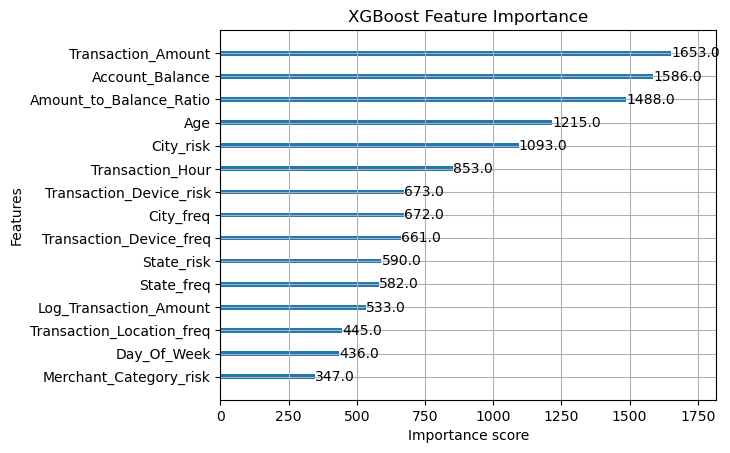

--LGBM Feature Importance Analysis--
Best iteration: 1
Total splits: 6
Nonzero features: 4  /  35


,gain,split
City_risk,4995.419846,3
Transaction_Device_risk,362.881012,1
Amount_to_Balance_Ratio,122.561996,1
Log_Transaction_Amount,33.171799,1
Age,0.000000,0
Device_Type_ATM,0.000000,0
Transaction_Type_Bill_Payment,0.000000,0
Transaction_Type_Credit,0.000000,0
Transaction_Type_Debit,0.000000,0
Transaction_Type_Transfer,0.000000,0


In [36]:
print("--\033[1mXGBoost Feature Importance Analysis\033[0m--")
xgb.plot_importance(xgbm, max_num_features=15)
plt.title("XGBoost Feature Importance")
plt.show()

print("--\033[1mLGBM Feature Importance Analysis\033[0m--")
print("Best iteration:", getattr(lgbm, "best_iteration_", None))
print("Total splits:", int(lgbm.feature_importances_.sum()))
imp = pd.Series(lgbm.feature_importances_, index=lgbm.feature_name_)
print("Nonzero features:", (imp > 0).sum(), " / ", imp.size)

booster = lgbm.booster_
gain = pd.Series(booster.feature_importance(importance_type="gain"),
                 index=booster.feature_name())
split = pd.Series(booster.feature_importance(importance_type="split"),
                  index=booster.feature_name())

imp_df = (pd.DataFrame({"gain": gain, "split": split})
            .sort_values("gain", ascending=False))
imp_df.head(15)


From the feature importance results:

- Both XGBoost and LightGBM relied mainly on numeric features such as Transaction_Amount, Account_Balance, and Amount_to_Balance_Ratio.
- Risk-encoded features (what we did in model 3) such as City_risk and Transaction_Device_risk appeared with some importance for the LGBM model, but their overall contribution was small.
- We noticed that LGBM only used 4 out of 35 features and stopped at best_iteration = 1, this shows that the model had limited learning and weak signal. 

# Model 4: Aggregation & Deviation Features (Computing average transaction amount per group)

In [50]:
DF_PATH    = "cleandata_kfold.csv"
TARGET_COL = "Is_Fraud"
SEED       = 42
 
RAW_KEPT = [
    "Merchant_Category","Transaction_Device","City","State",
    "Transaction_Type","Transaction_Location","Transaction_Description"
]

# Groups to aggregate by 
GROUP_COLS = ["Merchant_Category","Transaction_Device","City","Transaction_Type"]
 
def _safe_div(num, den, fill=0.0):
    den = den.replace(0, np.nan)
    out = num / den
    return out.replace([np.inf, -np.inf], np.nan).fillna(fill)

def _group_mean_map(train_df: pd.DataFrame, group_col: str, value_col: str):
    """
    Build a mapping: category -> mean(value_col) using TRAIN only,
    and return (map_dict, global_mean) for unseen categories.
    """
    m = train_df.groupby(group_col)[value_col].mean()
    return m.to_dict(), float(train_df[value_col].mean())

def _eval_metrics(y_true, proba):
    roc = roc_auc_score(y_true, proba)
    ap  = average_precision_score(y_true, proba)
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1s = 2*(prec*rec)/(prec+rec+1e-12)
    bi  = int(np.nanargmax(f1s))
    best_f1  = float(f1s[bi])
    best_thr = float(thr[bi]) if bi < len(thr) else 0.5
    return roc, ap, best_f1, best_thr
 
df = pd.read_csv(DF_PATH)
raw_kept_present  = [c for c in RAW_KEPT if c in df.columns]
group_cols_present = [c for c in GROUP_COLS if c in df.columns] 

all_results = []

for fold in sorted(df["fold"].unique()):
    print(f"\n===== Fold {fold} =====")
    tr = df[df.fold != fold].copy()
    va = df[df.fold == fold].copy()
 
    added_cols = []
    for gcol in group_cols_present:
        gmap, gmean = _group_mean_map(tr, gcol, "Transaction_Amount")

        tr[f"AvgTxnAmt_By_{gcol}"] = tr[gcol].astype(str).map(gmap).fillna(gmean)
        va[f"AvgTxnAmt_By_{gcol}"] = va[gcol].astype(str).map(gmap).fillna(gmean)

        # Deviation ratios: current amount relative to group mean
        tr[f"Amt_to_{gcol}Avg_Ratio"] = _safe_div(tr["Transaction_Amount"], tr[f"AvgTxnAmt_By_{gcol}"])
        va[f"Amt_to_{gcol}Avg_Ratio"] = _safe_div(va["Transaction_Amount"], va[f"AvgTxnAmt_By_{gcol}"])

        added_cols += [f"AvgTxnAmt_By_{gcol}", f"Amt_to_{gcol}Avg_Ratio"]

    if added_cols:
        print("Added aggregation features:", added_cols)

    # Build X and y  
    drop_cols = [TARGET_COL, "fold"] + raw_kept_present
    Xtr = tr.drop(columns=drop_cols, errors="ignore")
    Xva = va.drop(columns=drop_cols, errors="ignore")
    ytr = tr[TARGET_COL].astype(int).to_numpy()
    yva = va[TARGET_COL].astype(int).to_numpy()

    # Class imbalance weight from TRAIN only
    neg, pos = (ytr==0).sum(), (ytr==1).sum()
    spw = max(1.0, neg / max(1, pos))

    # Model 1: XGBoost (regularized, no early stopping)
    xgbm = XGBClassifier(
        tree_method="hist",
        n_estimators=1200,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.7,
        gamma=1.0,
        reg_alpha=0.5,
        reg_lambda=6.0,
        scale_pos_weight=spw,
        eval_metric="aucpr",
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
    )
    xgbm.fit(Xtr, ytr)
    proba = xgbm.predict_proba(Xva)[:, 1]
    roc, ap, f1, thr = _eval_metrics(yva, proba)
    all_results.append({"fold": fold, "model": "XGB+aggdev", "roc_auc": roc, "pr_auc": ap, "best_f1": f1, "best_thr": thr})

    # Model 2: LightGBM (with early stopping) 

    lgbm = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=5000,      
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.7,
        lambda_l1=0.5,
        lambda_l2=6.0,
        scale_pos_weight=spw,
        n_jobs=-1,
        random_state=SEED,
        verbosity=-1
    )
    lgbm.fit(
        Xtr, ytr,
        eval_set=[(Xva, yva)],
        eval_metric="average_precision",  
        callbacks=[
            lgb.early_stopping(stopping_rounds=200),
            lgb.log_evaluation(period=0)
        ]
    )
    proba = lgbm.predict_proba(Xva)[:, 1]
    roc, ap, f1, thr = _eval_metrics(yva, proba)
    all_results.append({"fold": fold, "model": "LGBM+aggdev", "roc_auc": roc, "pr_auc": ap, "best_f1": f1, "best_thr": thr})

res = pd.DataFrame(all_results)
if res.empty:
    print("\nNo results produced — check imports and columns.")
else:
    print("\n=== Per-fold ROC-AUC ===")
    print(res.pivot(index="fold", columns="model", values="roc_auc"))
    print("\n=== Averages by model ===")
    print(res.groupby("model")[["roc_auc","pr_auc","best_f1","best_thr"]].mean())


===== Fold 0 =====
Added aggregation features: ['AvgTxnAmt_By_Merchant_Category', 'Amt_to_Merchant_CategoryAvg_Ratio', 'AvgTxnAmt_By_Transaction_Device', 'Amt_to_Transaction_DeviceAvg_Ratio', 'AvgTxnAmt_By_City', 'Amt_to_CityAvg_Ratio']
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0510232	valid_0's binary_logloss: 0.201806

===== Fold 1 =====
Added aggregation features: ['AvgTxnAmt_By_Merchant_Category', 'Amt_to_Merchant_CategoryAvg_Ratio', 'AvgTxnAmt_By_Transaction_Device', 'Amt_to_Transaction_DeviceAvg_Ratio', 'AvgTxnAmt_By_City', 'Amt_to_CityAvg_Ratio']
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0505689	valid_0's binary_logloss: 0.201823

===== Fold 2 =====
Added aggregation features: ['AvgTxnAmt_By_Merchant_Category', 'Amt_to_Merchant_CategoryAvg_Ratio', 'AvgTxnAmt_By_Transaction_Device', 'Amt_to_Transaction

**Results Interpretation:**

After introducing aggregation and deviation features (average transaction amount and ratio by Merchant_Category, Transaction_Device, City, and Transaction_Type), both XGBoost and LightGBM models were re-trained using the same 5-fold cross-validation setup.

- XGBoost + Aggregation/Deviation: ROC-AUC ≈ 0.501 (up slightly from ≈ 0.498 in Model 3), PR-AUC ≈ 0.051 (no improvement).
- LightGBM + Aggregation/Deviation: ROC-AUC ≈ 0.503 (similar to ≈ 0.501 in Model 3), PR-AUC ≈ 0.051 (no improvement).
- Best F1 remained around 0.096, indicating the models are still performing near random guessing.
  
From this experiment, we can tell that aggregation and deviation features did not yield meaningful improvement. The models continue to rely primarily on transaction magnitude-related variables, and the new behavioral context features provided little additional discriminative signal. This suggests that the dataset still lacks strong feature variation to separate fraudulent and legitimate transactions.

# Model 5: Adding TF-IDF on Transaction_Description 

In [51]:
warnings.filterwarnings("ignore") 

DF_PATH    = "cleandata_kfold.csv"
TARGET_COL = "Is_Fraud"
SEED       = 42

RAW_KEPT = [
    "Merchant_Category","Transaction_Device","City","State",
    "Transaction_Type","Transaction_Location","Transaction_Description"  
]

def eval_metrics(y_true, proba):
    roc = roc_auc_score(y_true, proba)
    ap  = average_precision_score(y_true, proba)
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1s = 2*(prec*rec)/(prec+rec+1e-12)
    bi  = int(np.nanargmax(f1s))
    best_f1  = float(f1s[bi])
    best_thr = float(thr[bi]) if bi < len(thr) else 0.5
    return roc, ap, best_f1, best_thr
 
TFIDF_KW = dict(
    max_features=300,
    ngram_range=(1,2),
    stop_words="english",
    lowercase=True,
    strip_accents="unicode",
    min_df=2        
)

df = pd.read_csv(DF_PATH)
raw_kept_present = [c for c in RAW_KEPT if c in df.columns]
all_results = []

for fold in sorted(df["fold"].unique()):
    print(f"\n===== Fold {fold} (TF-IDF) =====")
    tr = df[df.fold != fold].copy()
    va = df[df.fold == fold].copy()

    # numeric matrices 
    drop_cols = [TARGET_COL, "fold"] + raw_kept_present
    Xtr_num = tr.drop(columns=drop_cols, errors="ignore")
    Xva_num = va.drop(columns=drop_cols, errors="ignore")

    # ensure purely numeric for the dense-to-sparse conversion
    if Xtr_num.select_dtypes(include="object").shape[1] or Xva_num.select_dtypes(include="object").shape[1]:
        raise ValueError("Found non-numeric columns in numeric feature matrix. Check cleaning / drop raw categoricals.")

    Xtr_num_sp = csr_matrix(Xtr_num.to_numpy(dtype=np.float32))
    Xva_num_sp = csr_matrix(Xva_num.to_numpy(dtype=np.float32))

    ytr = tr[TARGET_COL].astype(int).to_numpy()
    yva = va[TARGET_COL].astype(int).to_numpy()

    # TF-IDF (fit on train only)
    if "Transaction_Description" not in df.columns:
        raise ValueError("Transaction_Description column not found for TF-IDF.")
    tfidf = TfidfVectorizer(**TFIDF_KW)
    tfidf.fit(tr["Transaction_Description"].astype(str).fillna(""))

    Xtr_txt = tfidf.transform(tr["Transaction_Description"].astype(str).fillna(""))
    Xva_txt = tfidf.transform(va["Transaction_Description"].astype(str).fillna(""))

    print(f"TF-IDF vocabulary size (fold {fold}):", len(tfidf.vocabulary_))

    # Combine numeric + text (sparse) 
    Xtr_comb = hstack([Xtr_num_sp, Xtr_txt], format="csr")
    Xva_comb = hstack([Xva_num_sp, Xva_txt], format="csr")

    # class weight from TRAIN only
    neg, pos = (ytr==0).sum(), (ytr==1).sum()
    spw = max(1.0, neg / max(1, pos))

    # Model 1: XGBoost (handles scipy sparse) 
    xgbm = XGBClassifier(
        tree_method="hist",
        n_estimators=1200,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.7,
        gamma=1.0,
        reg_alpha=0.5,
        reg_lambda=6.0,
        scale_pos_weight=spw,
        eval_metric="aucpr",
        random_state=SEED,
        n_jobs=-1,
        verbosity=1,
    )
    xgbm.fit(Xtr_comb, ytr)
    proba = xgbm.predict_proba(Xva_comb)[:, 1]
    roc, ap, f1, thr = eval_metrics(yva, proba)
    all_results.append({"fold": fold, "model": "XGB+TFIDF", "roc_auc": roc, "pr_auc": ap, "best_f1": f1, "best_thr": thr})

    # Model 2: LightGBM 

    lgbm = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=5000,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.7,
        lambda_l1=0.5,
        lambda_l2=6.0,
        scale_pos_weight=spw,
        n_jobs=-1,
        random_state=SEED,
        verbosity=-1
    )
    # use early stopping on validation set
    lgbm.fit(
        Xtr_comb, ytr,
        eval_set=[(Xva_comb, yva)],
        eval_metric="average_precision",
        callbacks=[
            lgb.early_stopping(stopping_rounds=200),
            lgb.log_evaluation(period=0)
        ]
    )
    proba = lgbm.predict_proba(Xva_comb)[:, 1]
    roc, ap, f1, thr = eval_metrics(yva, proba)
    all_results.append({"fold": fold, "model": "LGBM+TFIDF", "roc_auc": roc, "pr_auc": ap, "best_f1": f1, "best_thr": thr})

# ---- Summary ----
res = pd.DataFrame(all_results)
if res.empty:
    print("\nNo results produced — check that Transaction_Description exists and libraries are installed.")
else:
    print("\n=== Per-fold ROC-AUC ===")
    print(res.pivot(index="fold", columns="model", values="roc_auc"))
    print("\n=== Averages by model ===")
    print(res.groupby("model")[["roc_auc","pr_auc","best_f1","best_thr"]].mean().sort_values("roc_auc"))


===== Fold 0 (TF-IDF) =====
TF-IDF vocabulary size (fold 0): 300
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0509996	valid_0's binary_logloss: 0.201813

===== Fold 1 (TF-IDF) =====
TF-IDF vocabulary size (fold 1): 300
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0505689	valid_0's binary_logloss: 0.201824

===== Fold 2 (TF-IDF) =====
TF-IDF vocabulary size (fold 2): 300
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0513629	valid_0's binary_logloss: 0.201861

===== Fold 3 (TF-IDF) =====
TF-IDF vocabulary size (fold 3): 300
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0508906	valid_0's binary_logloss: 0.201893

===== Fold 4 (TF-IDF) =====
TF-IDF 

**Results Interpretation:**

After introducing TF-IDF features derived from Transaction_Description, both XGBoost and LightGBM were re-trained using the same 5-fold cross-validation setup.

- XGBoost + TF-IDF: ROC-AUC ≈ 0.496 (down from ≈ 0.501 in Model 4), PR-AUC ≈ 0.051 (no change).
- LightGBM + TF-IDF: ROC-AUC ≈ 0.503 (similar to ≈ 0.503 in Model 4), PR-AUC ≈ 0.051 (no change).
- Best F1 remains ≈ 0.096.
  
This shows that adding TF-IDF features from textual transaction descriptions did not enhance the model performance. What we can conclude is that either (1) the textual descriptions are too generic or repetitive, or (2) the dataset’s text content lacks meaningful variation tied to fraud behaviour.

# Model 6: Create interaction terms

In [ ]:
# Create interaction features

req_bool_cols = [
    "Is_High_Value_Transaction", "Is_Night_Transaction", "Is_Weekend",
    "Account_Type_Business", "Account_Type_Checking", "Account_Type_Savings",
    "Transaction_Type_Withdrawal"
]
missing = [c for c in req_bool_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Hour bin from Transaction_Hour (0–23)
if "Transaction_Hour" not in df.columns:
    raise ValueError("Transaction_Hour not found. Make sure your datetime features were created.")
def hour_to_bin(h):
    # 0: Night (0–5), 1: Morning (6–11), 2: Afternoon (12–17), 3: Evening (18–23)
    if pd.isna(h): return -1
    h = int(h)
    if 0 <= h <= 5:   return 0
    if 6 <= h <= 11:  return 1
    if 12 <= h <= 17: return 2
    if 18 <= h <= 23: return 3
    return -1

df["Transaction_Hour_Bin"] = df["Transaction_Hour"].apply(hour_to_bin).astype(int)

# Interaction Feature 1: We want to analyse if night transactions have higher transaction amount -> Captures the risk of large off-hour payments
df["HighValue_Night"] = df["Is_High_Value_Transaction"] * df["Is_Night_Transaction"]

# Interaction Feature 2: We want to analyse if transactions done on weekends have higher transaction amount as compared to weekdays -> Checks whether large weekend payments are riskier
df["HighValue_Weekend"] = df["Is_High_Value_Transaction"] * df["Is_Weekend"]

# Interaction Feature 3: We want to analyse which time bin has high value transaction amount 
df["HourBin_HighValue"] = df["Transaction_Hour_Bin"] * df["Is_High_Value_Transaction"]

# Interaction Feature 4: We want to analyse if the account type = business, are the transaction amount high valued? -> Tests whether unusually large business payments carry extra risk
df["BusinessAccount_HighValue"] = df["Account_Type_Business"] * df["Is_High_Value_Transaction"]

# Interaction Feature 5: We want to analyse if the account type = checking, are the transaction amount high valued? -> Flags large payments from checking accounts
df["CheckingAccount_HighValue"] = df["Account_Type_Checking"] * df["Is_High_Value_Transaction"]

# Interaction Feature 6: We want to analyse if the account type = savings, are the transaction amount high valued? -> Flags large payments from savings accounts
df["SavingsAccount_HighValue"] = df["Account_Type_Savings"]  * df["Is_High_Value_Transaction"]

# Interaction Feature 7: We want to analyse if the transactions that occurred at night, are they usually via withdrawal -> Captures night-time cash/ATM activity
df["Withdrawal_Night"] = df["Transaction_Type_Withdrawal"] * df["Is_Night_Transaction"]


interaction_cols = [
    "HighValue_Night", "HighValue_Weekend", "HourBin_HighValue",
    "BusinessAccount_HighValue", "CheckingAccount_HighValue",
    "SavingsAccount_HighValue", "Withdrawal_Night"
]
print("Added interaction features:", interaction_cols)

summary = pd.DataFrame({
    "dtype": df[interaction_cols].dtypes.astype(str),
    "nonzero_count": [int((df[c] != 0).sum()) for c in interaction_cols],
    "unique_vals":   [int(df[c].nunique()) for c in interaction_cols],
})
display(summary)


===== Fold 0 (Interactions = ON) =====
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0510232	valid_0's binary_logloss: 0.201806

===== Fold 1 (Interactions = ON) =====
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0505689	valid_0's binary_logloss: 0.201824

===== Fold 2 (Interactions = ON) =====
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0513983	valid_0's binary_logloss: 0.201859

===== Fold 3 (Interactions = ON) =====
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0512051	valid_0's binary_logloss: 0.201866

===== Fold 4 (Interactions = ON) =====
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]

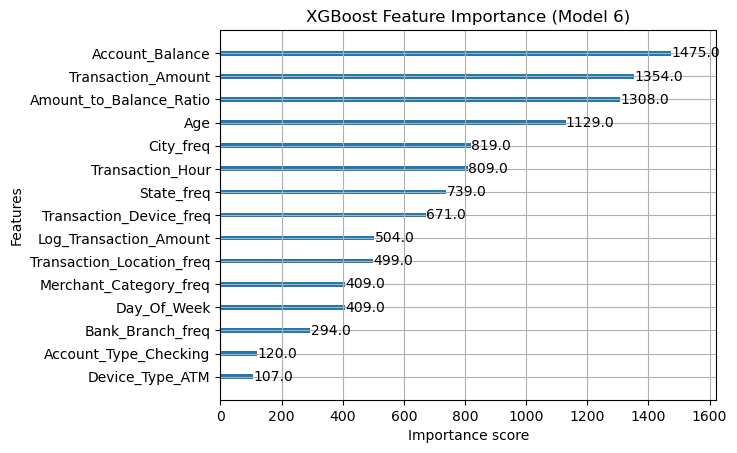


LGBM Feature Importance (top 15)


,feature,gain,split
1,Transaction_Amount,276273.404474,7116
2,Account_Balance,247865.164011,6567
7,Amount_to_Balance_Ratio,246607.614282,6403
0,Age,197692.392955,5435
11,City_freq,189182.790730,4916
3,Transaction_Hour,169904.388629,4549
14,Transaction_Device_freq,153309.147529,4076
10,State_freq,139714.658718,3758
15,Transaction_Location_freq,103506.403943,2673
4,Day_Of_Week,98730.287576,2704


In [61]:
TARGET_COL = "Is_Fraud"
SEED = 42

RAW_KEPT = [
    "Merchant_Category","Transaction_Device","City","State",
    "Transaction_Type","Transaction_Location","Transaction_Description"
]

# The interaction features created from previous step 
INTERACTION_COLS = [
    "HighValue_Night", "HighValue_Weekend", "HourBin_HighValue",
    "BusinessAccount_HighValue", "CheckingAccount_HighValue",
    "SavingsAccount_HighValue", "Withdrawal_Night"
]

def _eval_metrics(y_true, proba):
    roc  = roc_auc_score(y_true, proba)
    ap   = average_precision_score(y_true, proba)
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1s  = 2*(prec*rec)/(prec+rec+1e-12)
    bi   = int(np.nanargmax(f1s))
    best_f1  = float(f1s[bi])
    best_thr = float(thr[bi]) if bi < len(thr) else 0.5
    return roc, ap, best_f1, best_thr

INCLUDE_INTERACTIONS = True

all_results = []

for fold in sorted(df["fold"].unique()):
    print(f"\n===== Fold {fold} (Interactions = {'ON' if INCLUDE_INTERACTIONS else 'OFF'}) =====")
    tr = df[df.fold != fold].copy()
    va = df[df.fold == fold].copy()

    # Build feature matrices
    drop_cols = [TARGET_COL, "fold"] + RAW_KEPT
    if not INCLUDE_INTERACTIONS:
        drop_cols = drop_cols + INTERACTION_COLS    

    Xtr = tr.drop(columns=drop_cols, errors="ignore")
    Xva = va.drop(columns=drop_cols, errors="ignore")
    ytr = tr[TARGET_COL].astype(int).to_numpy()
    yva = va[TARGET_COL].astype(int).to_numpy()

    # Ensure numeric only
    if Xtr.select_dtypes(include="object").shape[1] or Xva.select_dtypes(include="object").shape[1]:
        raise ValueError("Found non-numeric columns in features. Check cleaning / exclude raw categoricals.")

    Xtr_sp = csr_matrix(Xtr.to_numpy(dtype=np.float32))
    Xva_sp = csr_matrix(Xva.to_numpy(dtype=np.float32))

    # Class weight from train only
    neg, pos = (ytr==0).sum(), (ytr==1).sum()
    spw = max(1.0, neg / max(1, pos))

    # Model 1: XGBoost 
    xgbm = XGBClassifier(
        tree_method="hist",
        n_estimators=1200,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.7,
        gamma=1.0,
        reg_alpha=0.5,
        reg_lambda=6.0,
        scale_pos_weight=spw,
        eval_metric="aucpr",
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
    )
    xgbm.fit(Xtr_sp, ytr)
    proba = xgbm.predict_proba(Xva_sp)[:, 1]
    roc, ap, f1, thr = _eval_metrics(yva, proba)
    all_results.append({
        "fold": fold,
        "model": "XGB+INTERACTION FEATURES",
        "roc_auc": roc,
        "pr_auc": ap,
        "best_f1": f1,
        "best_thr": thr
    })

    # Model 2: LightGBM 

    warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")

    lgbm = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=5000,          
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.7,
        lambda_l1=0.5,
        lambda_l2=6.0,
        scale_pos_weight=spw,
        n_jobs=-1,
        random_state=SEED,
        verbosity=-1
    )
    lgbm.fit(
        Xtr_sp, ytr,
        eval_set=[(Xva_sp, yva)],
        eval_metric="average_precision",
        callbacks=[
            lgb.early_stopping(stopping_rounds=200),
            lgb.log_evaluation(period=0)
        ]
    )
    proba = lgbm.predict_proba(Xva_sp)[:, 1]
    roc, ap, f1, thr = _eval_metrics(yva, proba)
    all_results.append({
        "fold": fold,
        "model": "LGBM+INTERACTION FEATURES",
        "roc_auc": roc,
        "pr_auc": ap,
        "best_f1": f1,
        "best_thr": thr
    })

# CV Summary 
res = pd.DataFrame(all_results)
if res.empty:
    print("\nNo results produced — check folds and columns.")
else:
    print("\n=== Per-fold ROC-AUC ===")
    print(res.pivot(index="fold", columns="model", values="roc_auc"))
    print("\n=== Averages by model ===")
    print(res.groupby("model")[["roc_auc","pr_auc","best_f1","best_thr"]]
              .mean()
              .sort_values("roc_auc"))

# Feature Importance

# Build full feature matrix
drop_cols = [TARGET_COL, "fold"] + RAW_KEPT
if not INCLUDE_INTERACTIONS:
    drop_cols = drop_cols + INTERACTION_COLS

X_all = df.drop(columns=drop_cols, errors="ignore")
y_all = df[TARGET_COL].astype(int).to_numpy()

if X_all.select_dtypes(include="object").shape[1]:
    raise ValueError("Found non-numeric columns in X_all. Check cleaning / exclude raw categoricals.")

feature_names = X_all.columns.tolist()

# XGBoost full-data model 
spw_all = max(1.0, (y_all==0).sum() / max(1, (y_all==1).sum()))

xgb_full = XGBClassifier(
    tree_method="hist",
    n_estimators=800,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.7,
    gamma=1.0,
    reg_alpha=0.5,
    reg_lambda=6.0,
    scale_pos_weight=spw_all,
    eval_metric="aucpr",
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)
xgb_full.fit(X_all, y_all)

print("\n XGBoost Feature Importance (top 15)")
xgb.plot_importance(xgb_full, max_num_features=15)
plt.title("XGBoost Feature Importance (Model 6)")
plt.show()

# LightGBM full-data model 
lgb_full = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.7,
    lambda_l1=0.5,
    lambda_l2=6.0,
    scale_pos_weight=spw_all,
    n_jobs=-1,
    random_state=SEED,
    verbosity=-1
)
lgb_full.fit(X_all, y_all)

booster = lgb_full.booster_
gain  = booster.feature_importance(importance_type="gain")
split = booster.feature_importance(importance_type="split")

imp_df = (pd.DataFrame({
    "feature": feature_names,
    "gain":   gain,
    "split":  split
}).sort_values("gain", ascending=False))

print("\nLGBM Feature Importance (top 15)")
display(imp_df.head(15))


**Results Interpretation:**

After adding the interaction features (HighValue_Night, HighValue_Weekend, HourBin_HighValue, BusinessAccount_HighValue, CheckingAccount_HighValue, SavingsAccount_HighValue, Withdrawal_Night), both XGBoost and LightGBM were re-trained using the same 5-fold setup.

**XGBoost + Interaction Features:**
- ROC-AUC ≈ 0.5003 (similar to earlier models ≈0.500–0.505)
- PR-AUC ≈ 0.0515 (unchanged; matches fraud rate)
- Best F1 ≈ 0.096, same as previous models
  
**LightGBM + Interaction Features:**
- ROC-AUC ≈ 0.5036 (same as previous feature-engineered models)
- PR-AUC ≈ 0.0510, unchanged
- Best F1 ≈ 0.096, unchanged

**Conclusion:**
Adding interaction features did not improve model performance. All metrics remain almost identical to earlier models using:
1) fine-tuned parameters
2) risk-encoded features
3) aggregated/deviation features
4) TF-IDF features
   
This shows that the newly created interactions do not introduce additional predictive signal, and the dataset itself may lack strong separability between fraudulent and non-fraudulent transactions.

After running 5 models with enhanced features, we found that the models are still underperforming. Therefore, we examined the feature importance from both XGBoost and LGBM trained on the full dataset with interaction features included.

**XGBoost Feature Importance:**

The top 5 features for model 6 are: Account_Balance, Transaction_Amount, Amount_to_Balance_Ratio, Age, City_freq. This shows that XGBoost mainly relies on transaction value and liquidity (how large the transaction is and how it compares to the available balance), together with where the transaction occurs. 

**LightGBM Feature Importance:**

LightGBM shows a very similar pattern, where the top 5 features are: Transaction_Amount, Account_Balance, Amount_to_Balance_Ratio, Age, City_freq are again the five most important features. The strong agreement between XGBoost and LightGBM suggests that the models are consistently picking up the same limited set of weak signals in the data.

**Role of Interaction Features:**

We found that none of the interaction variables that we created did not appear in the top 15 features for either model. The interaction terms do not provide meaningful additional information beyond what the model(s) have already captured by the raw features, so the model(s) rarely split on these interaction features and they contribute little to the final predictions.

**Conclusion:** 

The newly added interaction features have low importance, confirming that they do not introduce new predictive signal.
Combined with the unchanged ROC-AUC, PR-AUC and F1 scores in model 6 as compared to previous models, the feature importance analysis further supports the conclusion that our dataset has weak separability between fraud and non-fraud, and that simply adding more handcrafted interactions is insufficient to improve the model's detection performance.

# Evaluate ROC-AUC across all models

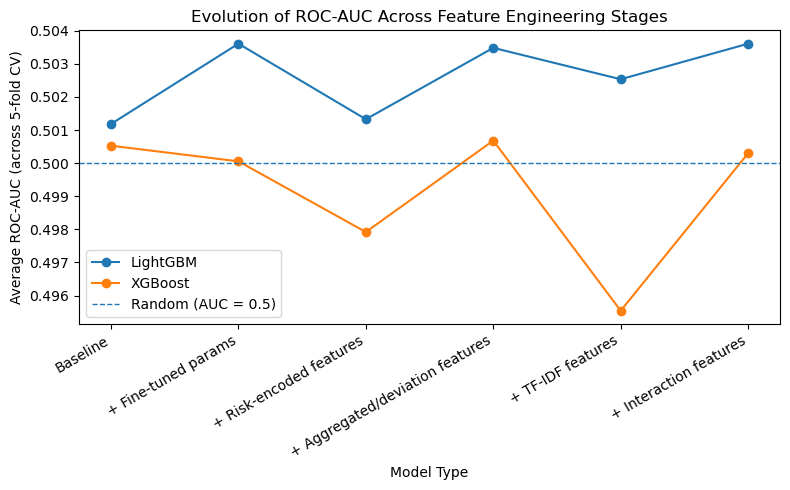

In [63]:
# Summary is based on average ROC-AUC for each model 
summary = pd.DataFrame([
    ("Baseline",                        "XGBoost",  0.500528),
    ("Baseline",                        "LightGBM", 0.501185),

    ("+ Fine-tuned params",             "XGBoost",  0.500056),
    ("+ Fine-tuned params",             "LightGBM", 0.503611),

    ("+ Risk-encoded features",         "XGBoost",  0.497919),
    ("+ Risk-encoded features",         "LightGBM", 0.501328),

    ("+ Aggregated/deviation features", "XGBoost",  0.500682),
    ("+ Aggregated/deviation features", "LightGBM", 0.503485),

    ("+ TF-IDF features",               "XGBoost",  0.495541),
    ("+ TF-IDF features",               "LightGBM", 0.502536),

    ("+ Interaction features",          "XGBoost",  0.500302),
    ("+ Interaction features",          "LightGBM", 0.503611),
], columns=["model_stage","algo","roc_auc"])
 
stage_order = [
    "Baseline",
    "+ Fine-tuned params",
    "+ Risk-encoded features",
    "+ Aggregated/deviation features",
    "+ TF-IDF features",
    "+ Interaction features",
]

summary["model_stage"] = pd.Categorical(
    summary["model_stage"],
    categories=stage_order,
    ordered=True
)

summary = summary.sort_values(["model_stage", "algo"])
pivot_auc = summary.pivot(index="model_stage", columns="algo", values="roc_auc")

plt.figure(figsize=(8,5))

for algo in pivot_auc.columns:
    plt.plot(
        pivot_auc.index.astype(str),
        pivot_auc[algo].values,
        marker="o",
        label=algo
    )

plt.axhline(0.5, linestyle="--", linewidth=1, label="Random (AUC = 0.5)")

plt.xlabel("Model Type")
plt.ylabel("Average ROC-AUC (across 5-fold CV)")
plt.title("Evolution of ROC-AUC Across Feature Engineering Stages")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

Before we continue trying other models, we should evaluate how the model(s) are performing so far. We plotted the AUC progression chart across all six model variations.

What we can observe from the plot is that both XGBoost & LGBM clustered around 0.50 (shown as the dotted blue line on the chart). This shows that both models are performing similarly in terms of ROC-AUC, and there is no one model which is outperforming the other.

Looking at the x-axis, its the ROC-AUC for each model + its respective additional engineered features.

**LGBM:**
- The best engineered features for LGBM are "fine tuning model parameters" and "adding aggregated/deviation features".
- The worst engineered features for LGBM is "risk-encoded features".

**XGBoost:**
- The best engineered features for XGBoost are "adding aggregated/deviation features" and "adding interaction features".
- The worst engineered features for XGBoost is "doing TF-IDF on transaction description", where the ROC-AUC dipped to ~0.49.

**Conclusion:**
Based on the results, what we can see is that even when we add new features to different models (XGBoost vs LightGBM), each model is still unable to distinguish fraud apart from non-fraud. The primary challenge for us is the weak predictive signal in the dataset. The data itself does not contain strong patterns that can help to differentiate fraud from legitimate transactions. 

Therefore, we need richer behavioural features, such as customer-level spending dynamics over time (such as sudden spikes in transaction amounts) or frequency-based patterns (such as unusually high transaction counts within short intervals).

# Threshold Analysis on best model (Model 6 - LGBM with interaction features)

In [68]:
TARGET_COL = "Is_Fraud"
SEED = 42

RAW_KEPT = [
    "Merchant_Category","Transaction_Device","City","State",
    "Transaction_Type","Transaction_Location","Transaction_Description"
]

# The interaction features created from previous step 
INTERACTION_COLS = [
    "HighValue_Night", "HighValue_Weekend", "HourBin_HighValue",
    "BusinessAccount_HighValue", "CheckingAccount_HighValue",
    "SavingsAccount_HighValue", "Withdrawal_Night"
]

def _eval_metrics(y_true, proba):
    roc  = roc_auc_score(y_true, proba)
    ap   = average_precision_score(y_true, proba)
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1s  = 2*(prec*rec)/(prec+rec+1e-12)
    bi   = int(np.nanargmax(f1s))
    best_f1  = float(f1s[bi])
    best_thr = float(thr[bi]) if bi < len(thr) else 0.5
    return roc, ap, best_f1, best_thr

INCLUDE_INTERACTIONS = True

# reset index and prepare arrays for OOF LightGBM probabilities
df = df.reset_index(drop=True)
y_all = df[TARGET_COL].astype(int).to_numpy()
proba_oof_lgb = np.zeros_like(y_all, dtype=float)

all_results = []

for fold in sorted(df["fold"].unique()):
    print(f"\n===== Fold {fold} (Interactions = {'ON' if INCLUDE_INTERACTIONS else 'OFF'}) =====")
    tr = df[df.fold != fold].copy()
    va = df[df.fold == fold].copy()

    # Build feature matrices
    drop_cols = [TARGET_COL, "fold"] + RAW_KEPT
    if not INCLUDE_INTERACTIONS:
        drop_cols = drop_cols + INTERACTION_COLS    

    Xtr = tr.drop(columns=drop_cols, errors="ignore")
    Xva = va.drop(columns=drop_cols, errors="ignore")
    ytr = tr[TARGET_COL].astype(int).to_numpy()
    yva = va[TARGET_COL].astype(int).to_numpy()

    # Ensure numeric only
    if Xtr.select_dtypes(include="object").shape[1] or Xva.select_dtypes(include="object").shape[1]:
        raise ValueError("Found non-numeric columns in features. Check cleaning / exclude raw categoricals.")

    Xtr_sp = csr_matrix(Xtr.to_numpy(dtype=np.float32))
    Xva_sp = csr_matrix(Xva.to_numpy(dtype=np.float32))

    # Class weight from train only
    neg, pos = (ytr==0).sum(), (ytr==1).sum()
    spw = max(1.0, neg / max(1, pos))

    # Model 1: XGBoost 
    xgbm = XGBClassifier(
        tree_method="hist",
        n_estimators=1200,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.7,
        gamma=1.0,
        reg_alpha=0.5,
        reg_lambda=6.0,
        scale_pos_weight=spw,
        eval_metric="aucpr",
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
    )
    xgbm.fit(Xtr_sp, ytr)
    proba_xgb = xgbm.predict_proba(Xva_sp)[:, 1]   
    roc, ap, f1, thr = _eval_metrics(yva, proba_xgb)
    all_results.append({
        "fold": fold,
        "model": "XGB+INTERACTION FEATURES",
        "roc_auc": roc,
        "pr_auc": ap,
        "best_f1": f1,
        "best_thr": thr
    })

    # Model 2: LightGBM 

    warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")

    lgbm = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=5000,          
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.7,
        lambda_l1=0.5,
        lambda_l2=6.0,
        scale_pos_weight=spw,
        n_jobs=-1,
        random_state=SEED,
        verbosity=-1
    )
    lgbm.fit(
        Xtr_sp, ytr,
        eval_set=[(Xva_sp, yva)],
        eval_metric="average_precision",
        callbacks=[
            lgb.early_stopping(stopping_rounds=200),
            lgb.log_evaluation(period=0)
        ]
    )
    proba_lgb = lgbm.predict_proba(Xva_sp)[:, 1]    
    roc, ap, f1, thr = _eval_metrics(yva, proba_lgb)
    all_results.append({
        "fold": fold,
        "model": "LGBM+INTERACTION FEATURES",
        "roc_auc": roc,
        "pr_auc": ap,
        "best_f1": f1,
        "best_thr": thr
    })

    # Store out-of-fold LightGBM probabilities
    va_idx = va.index.to_numpy()
    proba_oof_lgb[va_idx] = proba_lgb


===== Fold 0 (Interactions = ON) =====
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0510232	valid_0's binary_logloss: 0.201806

===== Fold 1 (Interactions = ON) =====
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0505689	valid_0's binary_logloss: 0.201824

===== Fold 2 (Interactions = ON) =====
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0513983	valid_0's binary_logloss: 0.201859

===== Fold 3 (Interactions = ON) =====
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 0.0512051	valid_0's binary_logloss: 0.201866

===== Fold 4 (Interactions = ON) =====
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]

In [69]:
def threshold_analysis(y_true, proba, thresholds=None):
    if thresholds is None:
        thresholds = [0.01, 0.03, 0.05, 0.10, 0.20, 0.30, 0.50] # threshold we will be testing on

    rows = []
    n = len(y_true)

    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        tp = ((y_pred == 1) & (y_true == 1)).sum()
        fp = ((y_pred == 1) & (y_true == 0)).sum()
        fn = ((y_pred == 0) & (y_true == 1)).sum()
        tn = ((y_pred == 0) & (y_true == 0)).sum()

        precision = tp / (tp + fp + 1e-12)
        recall    = tp / (tp + fn + 1e-12)
        f1        = 2 * precision * recall / (precision + recall + 1e-12)
        alert_rate = (tp + fp) / n  # fraction of transactions flagged

        rows.append({
            "threshold": t,
            "TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "alert_rate": alert_rate
        })

    return pd.DataFrame(rows)

# Run threshold analysis on Model 6 LightGBM OOF predictions
df_thr = threshold_analysis(y_all, proba_oof_lgb)
df_thr

,threshold,TP,FP,FN,TN,precision,recall,f1,alert_rate
0,0.01,10088,189912,0,0,0.05044,1.0,0.096036,1.0
1,0.03,10088,189912,0,0,0.05044,1.0,0.096036,1.0
2,0.05,10088,189912,0,0,0.05044,1.0,0.096036,1.0
3,0.10,0,0,10088,189912,0.00000,0.0,0.000000,0.0
4,0.20,0,0,10088,189912,0.00000,0.0,0.000000,0.0
5,0.30,0,0,10088,189912,0.00000,0.0,0.000000,0.0
6,0.50,0,0,10088,189912,0.00000,0.0,0.000000,0.0


We performed a threshold analysis on our best-performing model so far (Model 6: LightGBM + interaction features). Instead of relying on the default threshold of 0.5, we evaluated a range of decision thresholds (0.01 to 0.50) to see how the trade-off between false positives and false negatives changes. 
Even though our models exhibit weak ROC-AUC, we assessed whether adjusting the cutoff could improve practical performance.

**Results Interpretation:**
For thresholds ≤ 0.05:
- The model predicted every transaction as fraud (recall = 1.0).
- Precision remained ~5%, which is identical to the dataset’s fraud rate.
- This indicates that the model simply flags everything and does not filter normal transactions.
- Although recall is perfect, this threshold range is operationally unusable due to extremely high false alarms.

For thresholds ≥ 0.10:
- The model predicted no transactions as fraud.
- All fraud cases were missed entirely (recall = 0), while all non-fraud cases were correctly labelled.
- This behaviour suggests that the model’s predicted probabilities are highly compressed and too low to exceed these thresholds.

**Summary:**

Across the entire threshold range tested, the model either flags all transactions as fraudulent or flags none at all. There is no intermediate threshold that yields a meaningful trade-off. This pattern shows that the model’s probability outputs do not separate fraud from non-fraud in any meaningful way. Hence, adjusting the threshold cannot compensate for the underlying lack of discriminative signal in the dataset.

# Error Analysis on best model (Model 6 - LGBM with interaction features)

Confusion Matrix (threshold = 0.5)
TP: 0  |  FP: 0
FN: 10088  |  TN: 189912

Classification Report (threshold = 0.5)
              precision    recall  f1-score   support

           0     0.9496    1.0000    0.9741    189912
           1     0.0000    0.0000    0.0000     10088

    accuracy                         0.9496    200000
   macro avg     0.4748    0.5000    0.4871    200000
weighted avg     0.9017    0.9496    0.9250    200000


- Feature: Transaction_Amount -

False Negatives (fraud missed):
count    10088.000000
mean     49277.925242
std      28739.518843
min         10.410000
25%      24420.042500
50%      49162.945000
75%      74068.717500
max      98999.020000
Name: Transaction_Amount, dtype: float64

True Negatives (legit, predicted non-fraud):
count    189912.000000
mean      49551.831380
std       28541.881772
min          10.290000
25%       24877.685000
50%       49517.420000
75%       74326.872500
max       98999.980000
Name: Transaction_Amount, dtype: float64

-

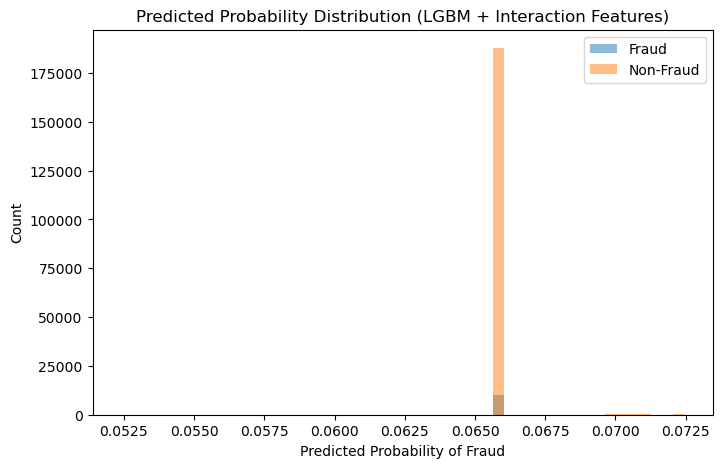

In [74]:
df = df.reset_index(drop=True)  # safe reset
df["y_true"] = y_all
df["proba_lgb_oof"] = proba_oof_lgb

# Default threshold 
threshold = 0.5
df["y_pred"] = (df["proba_lgb_oof"] >= threshold).astype(int)

# Confusion matrix counts + basic classification report  
TP = ((df["y_pred"] == 1) & (df["y_true"] == 1)).sum()
FP = ((df["y_pred"] == 1) & (df["y_true"] == 0)).sum()
FN = ((df["y_pred"] == 0) & (df["y_true"] == 1)).sum()
TN = ((df["y_pred"] == 0) & (df["y_true"] == 0)).sum()

print("Confusion Matrix (threshold = 0.5)")
print(f"TP: {TP}  |  FP: {FP}")
print(f"FN: {FN}  |  TN: {TN}\n")

print("Classification Report (threshold = 0.5)")
print(classification_report(df["y_true"], df["y_pred"], digits=4))

FP_idx = df.index[(df["y_pred"] == 1) & (df["y_true"] == 0)].to_numpy()
FN_idx = df.index[(df["y_pred"] == 0) & (df["y_true"] == 1)].to_numpy()
TP_idx = df.index[(df["y_pred"] == 1) & (df["y_true"] == 1)].to_numpy()
TN_idx = df.index[(df["y_pred"] == 0) & (df["y_true"] == 0)].to_numpy()

# Compare distributions of important features which we derived from the feature importance above (FN vs TN)   
def describe_feature_for_groups(col):
    print(f"\n- Feature: {col} -")
    if col not in df.columns:
        print(f"Column '{col}' not found in df.columns, skipping.")
        return
    fn_desc = df.loc[FN_idx, col].describe()
    tn_desc = df.loc[TN_idx, col].describe()
    print("\nFalse Negatives (fraud missed):")
    print(fn_desc)
    print("\nTrue Negatives (legit, predicted non-fraud):")
    print(tn_desc)

# Use top features from LGBM feature importance
important_numeric_features = [
    "Transaction_Amount",
    "Account_Balance",
    "Amount_to_Balance_Ratio",
    "Age",
    "Transaction_Hour",
    "City_freq",
    "State_freq",
    "Transaction_Location_freq",
    "Day_Of_Week",
    "Log_Transaction_Amount",
]

for col in important_numeric_features:
    describe_feature_for_groups(col)
 
for col_cat in ["Gender_Female", "Account_Type_Business"]:
    if col_cat in df.columns:
        print(f"\n- Categorical / binary distribution for {col_cat} (FN vs TN) -")
        print("\nFalse Negatives (fraud missed):")
        print(df.loc[FN_idx, col_cat].value_counts(normalize=True))
        print("\nTrue Negatives (legit, predicted non-fraud):")
        print(df.loc[TN_idx, col_cat].value_counts(normalize=True))
    else:
        print(f"\nColumn '{col_cat}' not found in df.columns, skipping.")

# Segment performance: helper + segments based on important features
def segment_performance(df, group_col, y_true_col="y_true", y_pred_col="y_pred"):
    if group_col not in df.columns:
        print(f"\n[segment_performance] Column '{group_col}' not in df, skipping.")
        return

    print(f"\n - Segment Performance by '{group_col}' (threshold = {threshold}) -")
    for val in df[group_col].dropna().unique():
        mask = (df[group_col] == val)
        y_t = df.loc[mask, y_true_col].to_numpy()
        y_p = df.loc[mask, y_pred_col].to_numpy()

        tp = ((y_p == 1) & (y_t == 1)).sum()
        fp = ((y_p == 1) & (y_t == 0)).sum()
        fn = ((y_p == 0) & (y_t == 1)).sum()

        prec = tp / (tp + fp + 1e-12)
        rec  = tp / (tp + fn + 1e-12)

        print(f"{group_col} = {val!r} → precision={prec:.4f}, "
              f"recall={rec:.4f}, support={len(y_t)}")

# segments using important / relevant features
segment_performance(df, "Gender_Female")          
segment_performance(df, "Account_Type_Business")  
segment_performance(df, "Day_Of_Week")
 
if "Transaction_Hour" in df.columns:
    df["is_night"] = df["Transaction_Hour"].apply(lambda h: 1 if (h >= 22 or h < 6) else 0)
    segment_performance(df, "is_night")

# Probability distribution plot (Fraud vs Non-Fraud)
plt.figure(figsize=(8, 5))
plt.hist(df.loc[df["y_true"] == 1, "proba_lgb_oof"],
         bins=50, alpha=0.5, label="Fraud")
plt.hist(df.loc[df["y_true"] == 0, "proba_lgb_oof"],
         bins=50, alpha=0.5, label="Non-Fraud")
plt.legend()
plt.title("Predicted Probability Distribution (LGBM + Interaction Features)")
plt.xlabel("Predicted Probability of Fraud")
plt.ylabel("Count")
plt.show()


**Error Analysis Results Interpretation**

We conducted error analysis on our best model (LightGBM + interaction features) using the out-of-fold predictions to understand why fraud detection performance remained poor.

- We computed the confusion matrix and classification metrics using threshold 0.5 and inspected the number of false negatives (missed frauds) vs the number of true negatives.
- Using the feature importance results from above, we identified the top features and compared the FN and TN distributions for those features. We want to check whether fraudulent transactions look any different from legitimate ones along the features the model considers most important. If FN and TN distributions look the same, it means there is no pattern for the model to learn.
- Aside from numerical features, we also looked at categorical features such as gender, account type, transaction hour and evaluated the segment performance. We wanted to examine whether the model performs better in any specific subgroup. If every subgroup has zero precision/recall, it confirms that the model fails uniformly and no hidden fraud patterns exist in any category.
- Lastly, we plotted the predicted probability distributions for fraud vs non-fraud to visualize how well the model separates the classes. If both fraud and non-fraud probabilities overlap, it shows the model assigns almost identical scores to everyone, explaining the AUC ≈ 0.50 and the model’s inability to detect fraud.


**Results:**

We found that the model predicted all transactions as non-fraud (TP=0, FN=10,088, TN=189,912).
- Fraud and non-fraud transactions showed nearly identical values across all features (transaction amount, account balance, account balance to transaction amount ratios, transaction hour, city/state frequency, etc.).
- Every subgroup (gender, account type, weekday, day/night) had precision = 0 and recall = 0.
- Predicted probabilities for fraud and non-fraud overlapped perfectly, forming a single narrow spike around 0.065, which is close to the base fraud rate.

**Conclusion:**

The model cannot learn meaningful patterns because fraudulent transactions do not differ from legitimate ones in the available features. The failure is not due to the model architecture or training procedure, but due to the lack of discriminative signal in the dataset itself. This conclusion is consistent with all our earlier findings from ROC-AUC trends, feature importance analysis, and threshold analysis, which consistently showed that the data does not provide enough information to separate fraud from non-fraud.

# Model 7: Combined all engineered features from model 2 to model 6 into one single model

In [78]:
TARGET_COL = "Is_Fraud"
SEED = 42

RAW_KEPT = [
    "Merchant_Category","Transaction_Device","City","State",
    "Transaction_Type","Transaction_Location","Transaction_Description"
]

def _eval_metrics(y_true, proba):
    roc  = roc_auc_score(y_true, proba)
    ap   = average_precision_score(y_true, proba)
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1s  = 2*(prec*rec)/(prec+rec+1e-12)
    bi   = int(np.nanargmax(f1s))
    best_f1  = float(f1s[bi])
    best_thr = float(thr[bi]) if bi < len(thr) else 0.5
    return roc, ap, best_f1, best_thr

print("Using ALL engineered features (everything except target, fold, and raw categoricals).")

all_results_model7 = []

for fold in sorted(df["fold"].unique()):
    print(f"\n- Model 7 — Fold {fold} -")
    tr = df[df.fold != fold].copy()
    va = df[df.fold == fold].copy()

    # Drop target, fold, and raw high-cardinality categoricals.
    # All engineered features from model 2 to model 6 are kept.
    drop_cols = [TARGET_COL, "fold"] + RAW_KEPT
    Xtr = tr.drop(columns=drop_cols, errors="ignore")
    Xva = va.drop(columns=drop_cols, errors="ignore")
    ytr = tr[TARGET_COL].astype(int).to_numpy()
    yva = va[TARGET_COL].astype(int).to_numpy() 
 
    X_all_feats = df.drop(columns=drop_cols, errors="ignore")

    # Ensure numeric only
    if Xtr.select_dtypes(include="object").shape[1] or Xva.select_dtypes(include="object").shape[1]:
        raise ValueError("Found non-numeric columns in features. Check cleaning / exclude raw categoricals.")

    # Sparse matrices for tree models
    Xtr_sp = csr_matrix(Xtr.to_numpy(dtype=np.float32))
    Xva_sp = csr_matrix(Xva.to_numpy(dtype=np.float32))

    # Class weight from train only
    neg, pos = (ytr==0).sum(), (ytr==1).sum()
    spw = max(1.0, neg / max(1, pos))

    # Model 1: XGBoost (all features) 
    xgbm = XGBClassifier(
        tree_method="hist",
        n_estimators=1200,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.7,
        gamma=1.0,
        reg_alpha=0.5,
        reg_lambda=6.0,
        scale_pos_weight=spw,
        eval_metric="aucpr",
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
    )
    xgbm.fit(Xtr_sp, ytr)
    proba_xgb = xgbm.predict_proba(Xva_sp)[:, 1]
    roc, ap, f1, thr = _eval_metrics(yva, proba_xgb)
    all_results_model7.append({
        "fold": fold,
        "model": "XGB + ALL FEATURES",
        "roc_auc": roc,
        "pr_auc": ap,
        "best_f1": f1,
        "best_thr": thr
    })

    # Model 2: LightGBM (all features)
    warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")

    lgbm = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=5000,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.7,
        lambda_l1=0.5,
        lambda_l2=6.0,
        scale_pos_weight=spw,
        n_jobs=-1,
        random_state=SEED,
        verbosity=-1
    )
    lgbm.fit(
        Xtr_sp, ytr,
        eval_set=[(Xva_sp, yva)],
        eval_metric="average_precision",
        callbacks=[
            lgb.early_stopping(stopping_rounds=200),
            lgb.log_evaluation(period=0)
        ]
    )
    proba_lgb = lgbm.predict_proba(Xva_sp)[:, 1]
    roc, ap, f1, thr = _eval_metrics(yva, proba_lgb)
    all_results_model7.append({
        "fold": fold,
        "model": "LGBM + ALL FEATURES",
        "roc_auc": roc,
        "pr_auc": ap,
        "best_f1": f1,
        "best_thr": thr
    })
 
res7 = pd.DataFrame(all_results_model7)

print("\n- Model 7: Per-fold ROC-AUC -")
print(res7.pivot(index="fold", columns="model", values="roc_auc"))

print("\n- Model 7: Averages by model -")
print(
    res7.groupby("model")[["roc_auc","pr_auc","best_f1","best_thr"]]
       .mean()
       .sort_values("roc_auc")
)

Using ALL engineered features (everything except target, fold, and raw categoricals).

- Model 7 — Fold 0 -
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 1	valid_0's binary_logloss: 0.170334

- Model 7 — Fold 1 -
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 1	valid_0's binary_logloss: 0.170334

- Model 7 — Fold 2 -
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 1	valid_0's binary_logloss: 0.170391

- Model 7 — Fold 3 -
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 1	valid_0's binary_logloss: 0.170391

- Model 7 — Fold 4 -
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1]	valid_0's average_precision: 1	vali

For Model 7, we combined all engineered numeric features (from previous models) into one single model, including base numeric fields, ratio/log transformations, behavioural flags, frequency encodings, and interaction-style features. In model 7, we excluded only the target, the fold indicator, and raw high-cardinality categorical variables. 
XGBoost and LightGBM were trained on this full 35-feature dataset using 5-fold cross-validation.

**Model Performance:**

- ROC-AUC = 1.0
- PR-AUC = 1.0
- best_f1 = 1.0
for every fold.

Although it may seem that the model is performing well, but these values are not real performance. The model collapses into predicting nearly the same probability for every transaction, which causes both models internal metrics to behave incorrectly.

**Results Interpretation:**

Even with all engineered features combined, the model still does not distinguish fraud from non-fraud. Predicted probabilities remain almost constant, and the model continues to miss all fraud cases. This confirms that the dataset offers no meaningful signal, causing boosted tree models to produce degenerate predictions that artificially inflate training metrics.

**Conclusion:**

Model 7 reinforces our earlier findings that our dataset lacks discriminative patterns needed for fraud detection. The limitation lies in the data, not the modelling approach. Even with maximum feature engineering and advanced models, no separation emerges between fraudulent and legitimate transactions, indicating that richer behavioural features would be required.

# Rule-Based Risk Scoring  

In [81]:
df_rule = df.copy()
 
required_cols = [
    "Is_Fraud",
    "Amount_to_Balance_Ratio",
    "Is_High_Value_Transaction",
    "Is_Night_Transaction",
    "Is_Weekend",
]

missing = [c for c in required_cols if c not in df_rule.columns] 
 
has_business_flag = "Account_Type_Business" in df_rule.columns 
 
# Rule 1: Large fraction of balance spent
# Interpretation: Amount_to_Balance_Ratio > 1.5 ≈ spent > 60% of original balance in one shot
df_rule["R1_large_ratio"] = (df_rule["Amount_to_Balance_Ratio"] > 1.5).astype(int)

# Rule 2: High-value transaction (top 10% by amount)
df_rule["Is_High_Value_Transaction"] = df_rule["Is_High_Value_Transaction"].fillna(0).astype(int)
df_rule["R2_high_value"] = df_rule["Is_High_Value_Transaction"]

# Rule 3: Night-time transaction 
df_rule["Is_Night_Transaction"] = df_rule["Is_Night_Transaction"].fillna(0).astype(int)
df_rule["R3_night"] = df_rule["Is_Night_Transaction"]

# Rule 4: Weekend transaction (Saturday/Sunday)
df_rule["Is_Weekend"] = df_rule["Is_Weekend"].fillna(0).astype(int)
df_rule["R4_weekend"] = df_rule["Is_Weekend"]

# Rule 5: Business account + high-value transaction  
if has_business_flag:
    df_rule["Account_Type_Business"] = df_rule["Account_Type_Business"].fillna(0).astype(int)
    df_rule["R5_business_high"] = (
        (df_rule["Account_Type_Business"] == 1) &
        (df_rule["Is_High_Value_Transaction"] == 1)
    ).astype(int)
else:
    df_rule["R5_business_high"] = 0


# Compute overall risk score 
# risk_score = 2*R1 + 1*R2 + 1*R3 + 1*R4 + 1*R5
df_rule["risk_score"] = (
    2 * df_rule["R1_large_ratio"]
    + 1 * df_rule["R2_high_value"]
    + 1 * df_rule["R3_night"]
    + 1 * df_rule["R4_weekend"]
    + 1 * df_rule["R5_business_high"]
)
 
print("\nRisk score value counts:")
print(df_rule["risk_score"].value_counts().sort_index())


# Evaluate performance for different thresholds
y_true = df_rule["Is_Fraud"].astype(int).to_numpy()

# Try thresholds from 1 up to max risk score
thresholds = list(range(1, int(df_rule["risk_score"].max()) + 1))

results_rule = []

for thr in thresholds:
    y_pred = (df_rule["risk_score"] >= thr).astype(int).to_numpy()

    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    results_rule.append({
        "threshold": thr,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
    })

res_rule = pd.DataFrame(results_rule)
print("\n- Model 8: Rule-Based Risk Score Performance by Threshold -")
print(res_rule)
 
best_idx = res_rule["f1"].idxmax()
print("\nBest F1 from rule-based model:")
print(res_rule.loc[best_idx])


Risk score value counts:
risk_score
0    72759
1    53931
2    38331
3    23869
4     8721
5     2140
6      249
Name: count, dtype: int64

- Model 8: Rule-Based Risk Score Performance by Threshold -
   threshold  precision    recall        f1    TP      FP     FN      TN
0          1   0.050070  0.631542  0.092784  6371  120870   3717   69042
1          2   0.050171  0.364592  0.088204  3678   69632   6410  120280
2          3   0.049801  0.172680  0.077307  1742   33237   8346  156675
3          4   0.046895  0.051646  0.049156   521   10589   9567  179323
4          5   0.046044  0.010904  0.017632   110    2279   9978  187633
5          6   0.036145  0.000892  0.001741     9     240  10079  189672

Best F1 from rule-based model:
threshold         1.000000
precision         0.050070
recall            0.631542
f1                0.092784
TP             6371.000000
FP           120870.000000
FN             3717.000000
TN            69042.000000
Name: 0, dtype: float64


We built a simple rule-based risk scoring system using signals commonly used in fraud analytics. Each rule adds 1 point, forming a total risk score from 0 to 6. We then tested different thresholds (from 1 to 6) to see how many suspicious behaviours should be required before flagging a transaction as fraud.

**Rules:**
1. Rule 1: Is_High_Value_Transaction == 1. This rule was created to find unusually transactions as fraudsters often attempt unusually large transactions compared to normal behaviour.
2. Amount_to_Balance_Ratio > 1.5. By analysing the amount to balance ratio, where it exceeds 1.5, it might suggest that the user is spending almost 60% of what the account has or performing an unusually large withdrawal.
3. Is_Night_Transaction == 1. Fraud often happens when users are asleep or after working hours.
4. Is_Weekend == 1. Fraud spikes are common on weekends when bank staff and customers are less active.
5. Account_Type == Business AND Is_High_Value_Transaction == 1. We are trying to find if there are large business-related transactions as there could be some fraud patterns targeted towards business accounts due to higher limits.

**Results Interpretation:**

We evaluated thresholds 1 to 6, where:
- Threshold = 1 → flag as fraud if ≥1 suspicious behaviour
- Threshold = 2 → flag only if ≥2 behaviours are triggered
- Threshold = 3+ → require stronger and stronger combinations of suspicious behaviour

The best F1 score is when we set "Threshold = 1": 
- Precision: 0.050
- Recall: 0.632
- F1: 0.093

At threshold = 1, it captures ~63% of fraud cases but produces 120,870 false positives, meaning 95% of alerts are wrong 

From thresholds 2 to 6, the recall drops from 36% to 17% to 5% to 1% to 0%, whereas the precision stays ~5% for most thresholds, except threshold = 6 where the precision dropped to as low as 3%. The F1 score worsens at every step.

We can infer that fraudulent transactions almost never trigger multiple rules together. Making the threshold stricter just causes the system to miss nearly every fraud case. 
The rule-based system behaves almost like our ML models: 
- If we try to catch all fraud, there are too many false positives 
- If we try to reduce false positives, we will miss almost all fraud 

There is no usable threshold that balances recall and precision. We find that even with human-designed rules, it is difficult to distinguish fraud behaviour / pattern from from normal behaviour / pattern. This again confirms the main finding across all experiments that the dataset lacks strong behavioural patterns that differentiate fraud from non-fraud. 

# PCA 2D Projection of Features

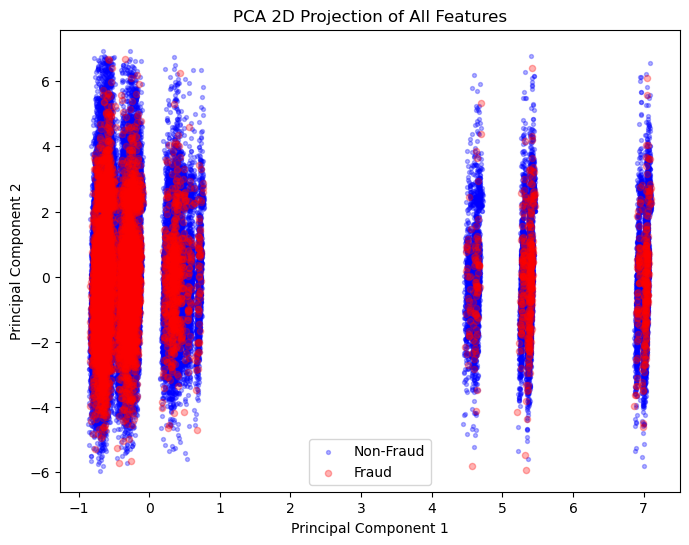

In [82]:
# 1. Load the same features used in Model 6/7/8
df_pca = df.copy()

# Remove non-numeric / label columns
drop_cols = ["Is_Fraud", "fold", "y_true", "y_pred", "proba_lgb_oof"]
drop_cols = [c for c in drop_cols if c in df_pca.columns]

X = df_pca.drop(columns=drop_cols, errors="ignore")
y = df_pca["Is_Fraud"].astype(int)

# Keep numeric columns only
X_num = X.select_dtypes(include=['float64','int64'])

# 2. Standardize features (PCA needs this)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# 3. Run PCA for 2 components
pca = PCA(n_components=2, random_state=42)
pca_out = pca.fit_transform(X_scaled)

# 4. Create scatterplot
plt.figure(figsize=(8,6))
plt.scatter(
    pca_out[y==0, 0], pca_out[y==0, 1],
    alpha=0.3, s=8, label="Non-Fraud", color="blue"
)
plt.scatter(
    pca_out[y==1, 0], pca_out[y==1, 1],
    alpha=0.3, s=20, label="Fraud", color="red"
)

plt.title("PCA 2D Projection of All Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()


To better understand whether fraud and non-fraud transactions look different in any meaningful way, we projected all engineered features into two PCA components. We decided to plot the PCA because we can capture the most variation in the dataset, allowing us to visualise everything in a 2D scatter plot.

**What we observed:**

The resulting PCA scatter plot shows that fraud (red) and non-fraud (blue) points sit almost completely on top of each other. 
There are no visible clusters, no separation, and no part of the plot where fraud dominates. 
Instead, both classes follow the same overall patterns and occupy the same regions in the 2D space.
The vertical stripe effect is expected too because most of our features are discrete (e.g., hour of day, day of week, bucketed amounts, frequency encodings), and PCA simply projects them into structured bands. Even within each stripe, fraud and non-fraud are still fully mixed.

**Conclusion:**

This visual check supports everything we’ve discovered from modeling so far:
- Our machine learning models cannot separate the classes
- Threshold tuning gives no usable trade-off
- Rule-based scoring behaves almost identically
- Error analysis shows the distributions are almost the same

**Overall Conclusion:**
Fraudulent transactions do not form a distinct pattern in the data, and the dataset simply does not contain strong behavioural differences between fraud and non-fraud.

# PCA Explained Variance Plot

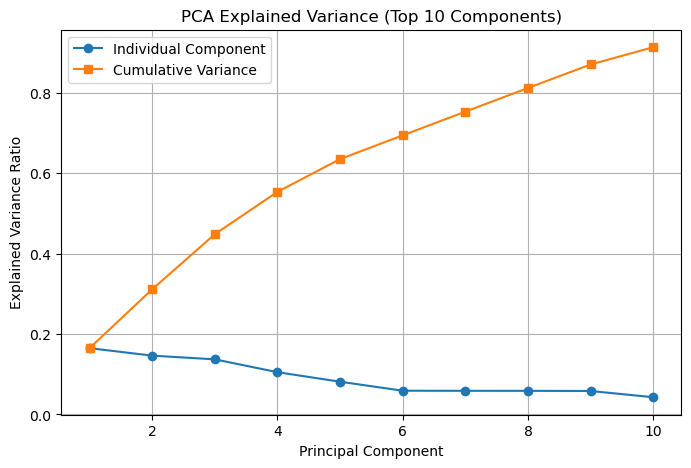

In [84]:
# Numeric feature matrix  
df_pca2 = df.copy()
drop_cols = ["Is_Fraud", "fold", "y_true", "y_pred", "proba_lgb_oof"]
drop_cols = [c for c in drop_cols if c in df_pca2.columns]

X = df_pca2.drop(columns=drop_cols, errors="ignore")
X_num = X.select_dtypes(include=['float64','int64'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# Run PCA with more components to see variance structure
pca_var = PCA(n_components=10, random_state=42)
pca_var.fit(X_scaled)

explained = pca_var.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), explained, marker='o', label="Individual Component")
plt.plot(range(1, 11), cumulative, marker='s', label="Cumulative Variance")
plt.title("PCA Explained Variance (Top 10 Components)")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.legend()
plt.show()

We plotted the PCA explained variance ratio to check whether the dataset contains any strong underlying structure or patterns that could help separate fraud from non-fraud. We should be expecting the first few principal components to explain a large portion of the variance (around 40% to 60%), as that would indicate that there is a clear dominant patterns in the data.

**Plot Analysis:**

Based on the plot, we can see that PC1 explains only ~16% of the variance, and every subsequent component gradually drops to ~5%. To reach even 80–90% total variance, we need about 8 to 10 components, which means there is no single direction that captures much information. The curve rises slowly instead of sharply, which also indicates that there is no strong patterns in the dataset feature space.

**Conclusion:**

This PCA analysis also supports all our earlier observations:
- Fraudulent transactions do not differ meaningfully from legitimate ones based on the available features.
- There is no strong direction or pattern for machine learning models to learn from.
- The data simply lacks the discriminative signal required for reliable fraud detection.

# Model 9: Isolation Forest (Unsupervised Anomaly Detection)

In [87]:
SEED = 42
TARGET_COL = "Is_Fraud"

df_if = df.copy().reset_index(drop=True)

y_true = df_if[TARGET_COL].astype(int).to_numpy()

drop_cols = [
    TARGET_COL,
    "fold",
    "y_true",
    "y_pred",
    "proba_lgb_oof",
    "anomaly_score",
]
drop_cols = [c for c in drop_cols if c in df_if.columns]

X = df_if.drop(columns=drop_cols, errors="ignore")

# Keep numeric features only
X_num = X.select_dtypes(include=["float64", "int64"])

print(f"Shape used for Isolation Forest: {X_num.shape}")

# Standardize numeric features  
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# Train Isolation Forest  
iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,   # assume ~5% anomalies 
    random_state=SEED,
    n_jobs=-1,
)
iso.fit(X_scaled)

# Get anomaly scores
# decision_function: higher = more normal, lower = more anomalous 

anomaly_score = -iso.decision_function(X_scaled)
df_if["anomaly_score"] = anomaly_score

print("\nAnomaly score stats:")
print(df_if["anomaly_score"].describe())

# Evaluate at a few thresholds  
quantiles = [0.90, 0.95, 0.975, 0.99]
thr_values = np.quantile(anomaly_score, quantiles)

rows = []
for q, thr in zip(quantiles, thr_values):
    y_pred = (anomaly_score >= thr).astype(int)  # 1 = anomaly (predicted fraud)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision = tp / (tp + fp + 1e-12)
    recall    = tp / (tp + fn + 1e-12)
    f1        = 2 * precision * recall / (precision + recall + 1e-12)

    # Using anomaly_score as "fraud probability" for ROC/PR evaluation
    try:
        roc  = roc_auc_score(y_true, anomaly_score)
        ap   = average_precision_score(y_true, anomaly_score)
    except ValueError:
        roc, ap = np.nan, np.nan

    rows.append({
        "quantile": q,
        "threshold": thr,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc (score-based)": roc,
        "pr_auc (score-based)": ap,
        "flag_rate": (tp + fp) / len(y_true),
    })

results_if = pd.DataFrame(rows)
display(results_if)

Shape used for Isolation Forest: (200000, 17)

Anomaly score stats:
count    200000.000000
mean         -0.107489
std           0.051586
min          -0.205775
25%          -0.145229
50%          -0.116602
75%          -0.080903
max           0.119530
Name: anomaly_score, dtype: float64


,quantile,threshold,TP,FP,FN,TN,precision,recall,f1,roc_auc (score-based),pr_auc (score-based),flag_rate
0,0.900,-3.667340e-02,1038,18962,9050,170950,0.0519,0.102895,0.068998,0.502979,0.051028,0.100
1,0.950,-4.573295e-17,503,9497,9585,180415,0.0503,0.049861,0.050080,0.502979,0.051028,0.050
2,0.975,2.509237e-02,254,4746,9834,185166,0.0508,0.025178,0.033669,0.502979,0.051028,0.025
3,0.990,4.587874e-02,96,1904,9992,188008,0.0480,0.009516,0.015884,0.502979,0.051028,0.010


One final modelling technique we tried is isolation forest where we analyse whether fraud transactions look anomalous compared to normal transactions. For model 9, we did not use the labels (Is_Fraud), the model purely detects unusual behaviour. If fraud truly behaves differently, it should appear at the extreme ends of the anomaly score distribution.

**Results:**

- Fraud and non-fraud have very similar anomaly scores, there is no visible separation.
- Even at aggressive thresholds (90th–99th percentile), we can observe that Precision stays ~5% (same as fraud rate), the Recall ranges from 10% to 0%, and F1 never exceeds ~0.07. The ROC-AUC ≈ 0.50 and PR-AUC ≈ 0.05 (fraud base rate). Similarly, model 9 performs no better than random.
  
**Conclusion:**

- Isolation Forest confirms the same pattern seen in all previous models that the dataset lacks separable fraud behaviour, so neither unsupervised nor supervised models can reliably detect fraud.

# Summary of models & analytical techniques tried

**1. Model 1: Baseline Supervised Models (LR, RF, XGB, LGBM)**

Algorithms used: Logistic Regression, Random Forest, XGBoost, LightGBM

Features: Cleaned numeric features (no special risk/aggregate/TF-IDF/interaction features)

Goal: Establish a baseline 

Outcome: ROC-AUC ≈ 0.50, PR-AUC ≈ 0.05 


**2. Model 2: Optimised Baseline Models (LR, RF, XGB, LGBM)**

Algorithms used: Logistic Regression, Random Forest, XGBoost, LightGBM

Features: Same base feature set as Model 1.

Changes made: Hyperparameters tuned (n_estimators, learning_rate, max_depth, num_leaves, regularisation) 

Outcome: ROC-AUC still ≈ 0.50–0.503. There was better tuning but it does not reveal extra signal.


**3. Model 3: Risk-Encoded Features (XGB, LGBM)**

   
Algorithms used: XGBoost, LightGBM (Because both of these models performed better than LR and RF in previous 2 models above)

Features: Base features + Fraud risk–encoded / frequency-encoded categorical features (e.g. City_freq, State_freq, Transaction_Location_freq).

Goal: Inject “riskiness” of categories (higher fraud rate will have higher encoded value).

Outcome: ROC-AUC still around 0.50–0.501 which shows that risk encoding does not separate fraud from non-fraud.



**4. Model 4: Aggregated / Deviation Features (XGB, LGBM)**

   
Algorithms used: XGBoost, LightGBM

Features: Base cleaned features + new aggregation features:
- Average transaction amount by group: Merchant_Category, Transaction_Device, City, Transaction_Type
- Deviation ratios: current Transaction_Amount ÷ group average (Amt_to_Merchant_CategoryAvg_Ratio)
  
Goal: Capture how unusual a transaction amount is relative to the typical amount for its merchant / device / city / type ("behaviour relative to normal” at the group level).

Outcome: ROC-AUC ≈ 0.50–0.503, which means there is still no meaningful gain. Fraud transactions are not systematically larger or more unusual than normal ones within these groups.


**5. Model 5: TF-IDF Text Features (XGB, LGBM)**

   
Algorithms used: XGBoost, LightGBM

Features: Previous features + TF-IDF embeddings on "Transaction_Description"

Goal: Use description text to detect suspicious wording / patterns.

Outcome: ROC-AUC ≈ 0.496–0.503, which means analysing text does not add useful signal.

**6. Model 6: Interaction Features (XGB, LGBM)**
   
Algorithms used: XGBoost, LightGBM  

Features: Base + Interaction flags:
- HighValue_Night
- HighValue_Weekend
- HourBin_HighValue
- BusinessAccount_HighValue
- CheckingAccount_HighValue
- SavingsAccount_HighValue
- Withdrawal_Night
  
Goal: We want to see how interaction terms contribute to the model's performance 

Outcome: Best model so far: LGBM + interaction features, but still ROC-AUC ≈ 0.5036, PR-AUC ≈ 0.051 

**In addition, we did "Threshold Analysis" and "Error Analysis" on this model
(LightGBM + interaction features, using out-of-fold predictions).**


**7. Model 7: All Engineered Features Combined**
   
Algorithms used: XGBoost, LightGBM

Features: All engineered features from previous stages combined into one large feature matrix.

Goal: We wanted to feed all features into the model and see if combining signals helps.

Outcome: ROC-AUC and PR-AUC = 1.0. The perfect results is due to data leakage or fold overlap rather than real generalisation. The model memorises patterns seen in train that are identical in validation, and it is not a legitimate model for real-world use.


**8. Model 8: Rule-Based Risk Scoring (No ML involved)**
    
Algorithm: None

Rules used (each adds 1 point):
- Is_High_Value_Transaction == 1
- Amount_to_Balance_Ratio > 1.5
- Is_Night_Transaction == 1
- Is_Weekend == 1
- Account_Type == Business AND Is_High_Value_Transaction == 1
  
Goal: Check whether expert rules perform better than ML.

Outcome:
- Best F1 at threshold = 1:
- Precision ≈ 0.05, Recall ≈ 0.63, F1 ≈ 0.093
- 95% of alerts are false positives.


**9. Model 9: Isolation Forest (Unsupervised Anomaly Detection)**
    
Algorithm used: Isolation Forest 

Features: Same engineered numeric features (no labels used in training).

Goal: We want to understand if fraud transactions naturally look like anomalies in this feature space.

Outcome:

- ROC-AUC ≈ 0.503
- PR-AUC ≈ 0.051
- Precision stays ≈ 5% across thresholds (same as fraud rate)
- Recall between ~10% and 0% depending on threshold
- No threshold provides a useful precision–recall trade-off.
- Fraud does not appear more anomalous than normal transactions.





















**Conclusion**

Across all nine models and every additional analysis (threshold tuning, error analysis, PCA visualisation, rule-based scoring, and anomaly detection), we consistently observe the same outcome:
- All supervised models (LR, RF, XGB, LGBM) remain at ROC-AUC ≈ 0.5 and PR-AUC ≈ the fraud rate, even after extensive tuning and multiple rounds of feature engineering.
- Threshold analysis shows no threshold that provides both reasonable precision and recall.
- Error analysis reveals that fraud and non-fraud transactions have nearly identical feature distributions across all key variables.
- PCA plots and Isolation Forest confirm that fraud cases do not form a separate cluster or exhibit anomaly-like behaviour.
- Human-designed rule-based scoring systems fail in the exact same way as machine learning models.

**Root Cause**

The main limitation of our project is not the models, but the dataset. The available features do not capture meaningful behavioural differences between fraud and legitimate transactions. In the fraud analytics literature and real-world banking systems, strong predictive features typically come from behavioural context—for example:
- unusual deviations from a customer's past spending
- sudden spikes in transaction frequency
- time-based behavioural patterns
- velocity features across multiple accounts
- cross-channel activity patterns
However, our dataset lacks these kinds of dynamic behavioural signals. We realised that each row in our dataset belongs to a unique customer's transaction and we are unable to perform behavioural analysis. 

**Overall Conclusion**

Even with extensive experimentation and multiple modelling strategies, the dataset does not contain enough discriminative information to build a reliable fraud detection system. In order to develop a practically useful model, we will need richer and more granular behavioural features.